# RegioneReloaded for 80k: NGN2 vs undiffWTC11
1. load the combined data
2. write down only the dCREs positive and dCREs negative
3. example run of regioneReloaded to get the overlap with the ReMap info

In [1]:
import pandas as pd
import os
import yaml


config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()

# load helpful functions
import sys
sys.path.append('../../00_helpful_functions')
import helpful_functions as hf

# column names
col_name = 'name'
col_header = 'name'
col_sequence = 'sequence'
col_category = 'category'
col_class = 'class'
col_source = 'source'
col_ref = 'ref'
col_chr = 'chr'
col_start = 'start'
col_end = 'end'
col_strand = 'strand'
col_variant_class = 'variant_class'
col_variant_pos = 'variant_pos'
col_SPDI = 'SPDI'
col_allele = 'allele'
col_info = 'info'

In [2]:
# read the file
df_elements_all_regions = pd.read_csv(config['files']['creating']['element_info_ngn2_undiffwtc11_202506'], sep='\t')

# make the start and end to integers
df_elements_all_regions[col_start] = df_elements_all_regions[col_start].astype(int)
df_elements_all_regions[col_end] = df_elements_all_regions[col_end].astype(int)

df_elements_all_regions

,name,chr,start,end,strand,sequence,label,raw_activity_NGN2_log2FC_bcalm,bcalm_adj_p_NGN2,normalized_activity_NGN2,...,SCREEN_ID,is_NPC_SCREEN_cCRE,is_WTC11_SCREEN_cCRE,is_H9_SCREEN_cCRE,is_H1_SCREEN_cCRE,is_dCRE_NGN2,is_dCRE_undiffWTC11,bcalm_effect_NGN2,bcalm_effect_undiffWTC11,measured_in_both_celltypes
0,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70276484,70276754,-,CTTGAATTTGAATTTAGAGTGAACATGTTGTGATTTTGTATCTGTG...,tested,-0.089726,2.492488e-03,-1.928542,...,EH38E1825144,False,False,False,False,True,False,decreasing,no_effect,True
1,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70323127,70323397,-,GCAGTGGCTCATGCCTGCAATCTCAGCACTTCGGGAGGTTGAGGTG...,tested,-0.026591,1.000000e+00,-0.295843,...,EH38E1825170,False,False,False,False,False,False,no_effect,no_effect,True
2,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70325057,70325327,-,GCAAGGATCTAAAGTTCCAATTGGCATTAGCTTTCTTTTCGTTTAC...,tested,-0.033114,1.000000e+00,-0.464529,...,EH38E1825171,False,False,False,False,False,False,no_effect,no_effect,True
3,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70213614,70213884,-,TTTTTTCAGGAAGTGAAGAATTTAGAGGGATAAAAGGCGGAAATAA...,tested,-0.018290,1.000000e+00,-0.081174,...,EH38E3188739,False,False,False,False,False,False,no_effect,no_effect,True
4,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70277149,70277419,-,ATCTGGCAGGCCTTTCCCCTCTGCAGGTGGTGTCACTCGTGGTGGT...,tested,-0.038026,1.000000e+00,-0.591552,...,EH38E3188758,False,False,False,False,False,False,no_effect,no_effect,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73935,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,106984308,106984578,+,TAGAAAAGCACAATGAACTGAAACCTTACAAATGCCAGCTCTGCTA...,tested,-0.076844,1.000000e+00,-1.595406,...,EH38E3899597,False,False,False,False,False,False,no_effect,no_effect,True
73936,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107008116,107008386,+,AAGCAGAATCCTCCCCACCCCCCTCTCATTATGCAGTTGGGGAGGA...,tested,0.138223,8.599369e-22,3.966275,...,EH38E3899600,False,False,False,False,True,False,increasing,no_effect,True
73937,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107019262,107019532,+,GAAGAGGTCCCCTGGGTCTGAAAATTATAATAGACGGCAGCAGTGA...,tested,0.054619,3.581264e-01,1.804262,...,EH38E3899604,False,False,False,False,False,False,no_effect,no_effect,True
73938,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107038939,107039209,+,CTGTCTTCAAGCATCCTAAATCTTTTATATGAGTGTCTCTAGAAGG...,tested,-0.064615,1.000000e+00,-1.279153,...,EH38E3899614,False,False,False,False,False,False,no_effect,no_effect,True


In [3]:
df_elements = df_elements_all_regions.loc[df_elements_all_regions['measured_in_both_celltypes']].copy()

## Group the data: 
- get dCREs in NGN2 more active than scrambled
- get dCREs in NGN2 less active than scrambled
- get CREs which are not dCREs in NGN2 and not in undiffWTC11
- get subsampled set of not dCREs which has a similar number of CREs as the mean number of dCREs in NGN2 and undiffWTC11

In [4]:
# TODO: 1.5h

In [5]:
df_elements.columns

Index(['name', 'chr', 'start', 'end', 'strand', 'sequence', 'label',
       'raw_activity_NGN2_log2FC_bcalm', 'bcalm_adj_p_NGN2',
       'normalized_activity_NGN2', 'bcalm_data_exists_NGN2',
       'raw_activity_undiffWTC11_log2FC_bcalm', 'bcalm_adj_p_undiffWTC11',
       'normalized_activity_undiffWTC11', 'bcalm_data_exists_undiffWTC11',
       'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_WTC11_SCREEN_cCRE',
       'is_H9_SCREEN_cCRE', 'is_H1_SCREEN_cCRE', 'is_dCRE_NGN2',
       'is_dCRE_undiffWTC11', 'bcalm_effect_NGN2', 'bcalm_effect_undiffWTC11',
       'measured_in_both_celltypes'],
      dtype='object')

In [6]:
df_elements.bcalm_effect_NGN2.value_counts()

bcalm_effect_NGN2
no_effect     63714
increasing     2309
decreasing     1428
Name: count, dtype: int64

In [7]:
df_elements.bcalm_effect_undiffWTC11.value_counts()

bcalm_effect_undiffWTC11
no_effect     67025
increasing      393
decreasing       33
Name: count, dtype: int64

### Investigate the group distributions (Upset plot vs all sequences)

/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth

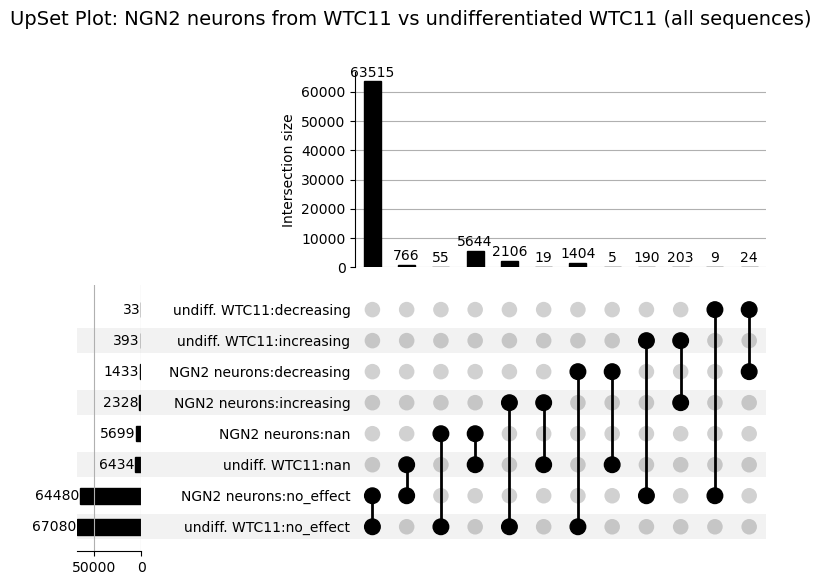

In [8]:
from upsetplot import from_memberships, UpSet
import matplotlib.pyplot as plt
# Create a combined membership list for each row
memberships = df_elements_all_regions.apply(lambda row: (f"NGN2 neurons:{row['bcalm_effect_NGN2']}", f"undiff. WTC11:{row['bcalm_effect_undiffWTC11']}"), axis=1)

# Step 2: Count how many times each membership combination occurs
membership_counts = memberships.value_counts()

# Count occurrences of each unique combination
data = from_memberships(membership_counts.index, data=membership_counts.values)


# Plot the UpSet
upset = UpSet(data, show_counts=True)
upset.plot()
plt.suptitle("UpSet Plot: NGN2 neurons from WTC11 vs undifferentiated WTC11 (all sequences)", fontsize=14)
plt.tight_layout()
plt.show()

/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth

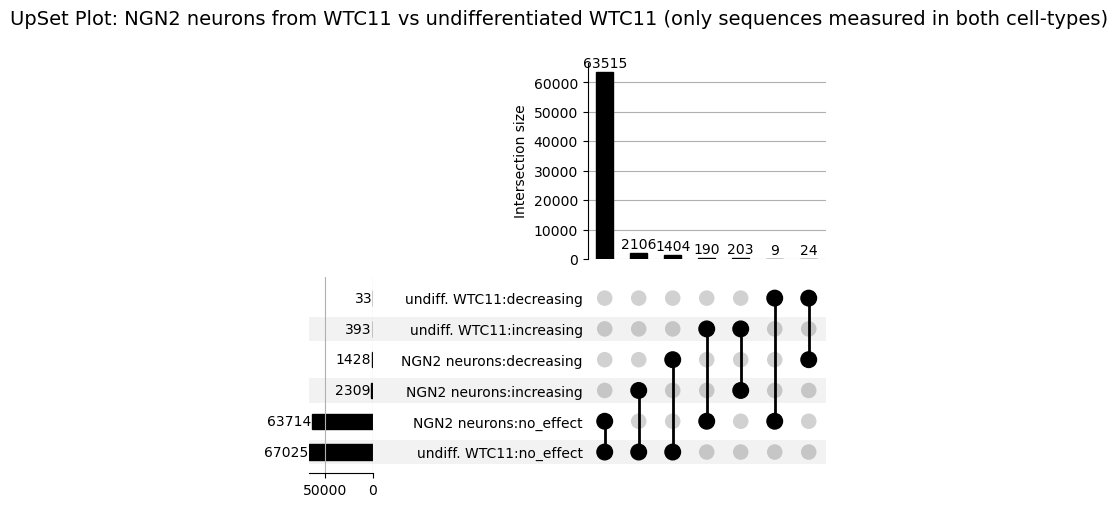

In [9]:
from upsetplot import from_memberships, UpSet
import matplotlib.pyplot as plt
# Create a combined membership list for each row
memberships = df_elements.apply(lambda row: (f"NGN2 neurons:{row['bcalm_effect_NGN2']}", f"undiff. WTC11:{row['bcalm_effect_undiffWTC11']}"), axis=1)

# Step 2: Count how many times each membership combination occurs
membership_counts = memberships.value_counts()

# Count occurrences of each unique combination
data = from_memberships(membership_counts.index, data=membership_counts.values)


# Plot the UpSet
upset = UpSet(data, show_counts=True)
upset.plot()
plt.suptitle("UpSet Plot: NGN2 neurons from WTC11 vs undifferentiated WTC11 (only sequences measured in both cell-types)", fontsize=14)
plt.tight_layout()
plt.show()

#### Without alternative sequences: 

In [27]:
df_elements_no_alt.columns

Index(['name', 'chr', 'start', 'end', 'strand', 'sequence', 'label',
       'raw_activity_NGN2_log2FC_bcalm', 'bcalm_adj_p_NGN2',
       'normalized_activity_NGN2', 'bcalm_data_exists_NGN2',
       'raw_activity_undiffWTC11_log2FC_bcalm', 'bcalm_adj_p_undiffWTC11',
       'normalized_activity_undiffWTC11', 'bcalm_data_exists_undiffWTC11',
       'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_WTC11_SCREEN_cCRE',
       'is_H9_SCREEN_cCRE', 'is_H1_SCREEN_cCRE', 'is_dCRE_NGN2',
       'is_dCRE_undiffWTC11', 'bcalm_effect_NGN2', 'bcalm_effect_undiffWTC11',
       'measured_in_both_celltypes', 'region_definition'],
      dtype='object')

In [ ]:
df_elements_no_alt

In [10]:
df_elements_no_alt = df_elements_all_regions.loc[~df_elements_all_regions['name'].str.startswith("cardiac_neuro_cava_random:ALT_")].copy()

df_elements_no_alt_measured_in_both = df_elements_no_alt.loc[df_elements_no_alt['measured_in_both_celltypes']].copy()

/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth

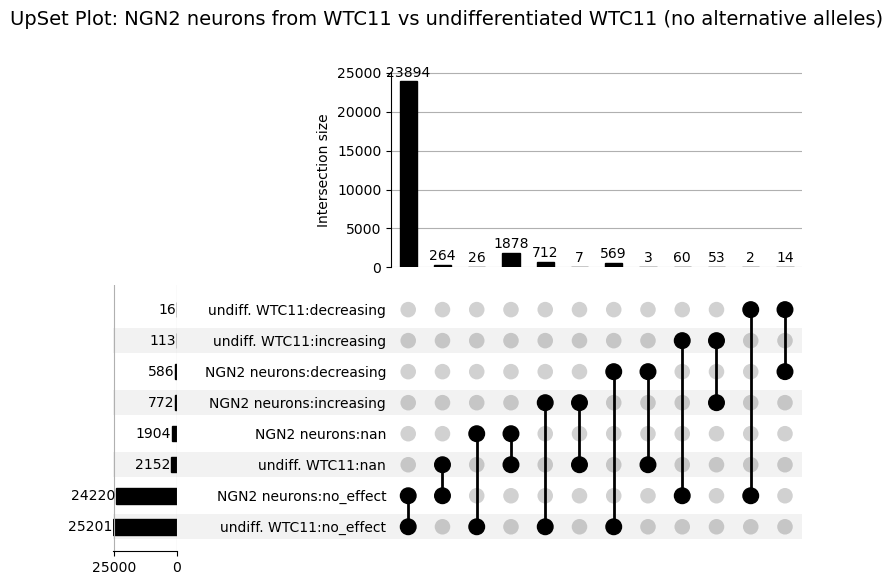

In [11]:
from upsetplot import from_memberships, UpSet
import matplotlib.pyplot as plt
# Create a combined membership list for each row
memberships = df_elements_no_alt.apply(lambda row: (f"NGN2 neurons:{row['bcalm_effect_NGN2']}", f"undiff. WTC11:{row['bcalm_effect_undiffWTC11']}"), axis=1)

# Step 2: Count how many times each membership combination occurs
membership_counts = memberships.value_counts()

# Count occurrences of each unique combination
data = from_memberships(membership_counts.index, data=membership_counts.values)


# Plot the UpSet
upset = UpSet(data, show_counts=True)
upset.plot()
plt.suptitle("UpSet Plot: NGN2 neurons from WTC11 vs undifferentiated WTC11 (no alternative alleles)", fontsize=14)
plt.tight_layout()
plt.show()

/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth

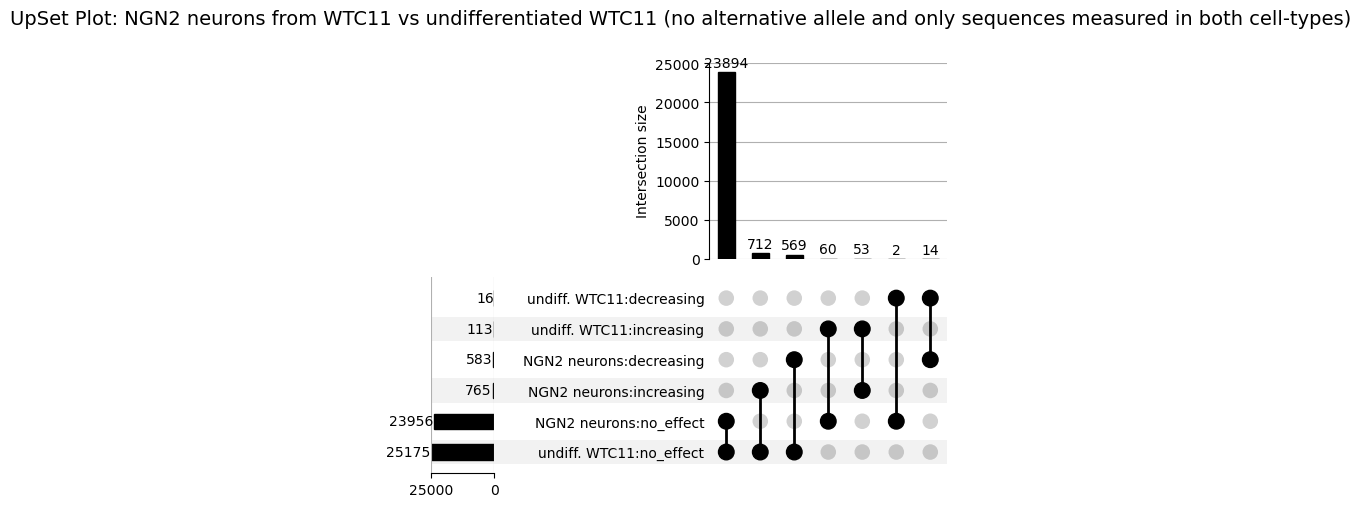

In [12]:
from upsetplot import from_memberships, UpSet
import matplotlib.pyplot as plt
# Create a combined membership list for each row
memberships = df_elements_no_alt_measured_in_both.apply(lambda row: (f"NGN2 neurons:{row['bcalm_effect_NGN2']}", f"undiff. WTC11:{row['bcalm_effect_undiffWTC11']}"), axis=1)

# Step 2: Count how many times each membership combination occurs
membership_counts = memberships.value_counts()

# Count occurrences of each unique combination
data = from_memberships(membership_counts.index, data=membership_counts.values)


# Plot the UpSet
upset = UpSet(data, show_counts=True)
upset.plot()
plt.suptitle("UpSet Plot: NGN2 neurons from WTC11 vs undifferentiated WTC11 (no alternative allele and only sequences measured in both cell-types)", fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
df_elements_all_regions

,name,chr,start,end,strand,sequence,label,raw_activity_NGN2_log2FC_bcalm,bcalm_adj_p_NGN2,normalized_activity_NGN2,...,SCREEN_ID,is_NPC_SCREEN_cCRE,is_WTC11_SCREEN_cCRE,is_H9_SCREEN_cCRE,is_H1_SCREEN_cCRE,is_dCRE_NGN2,is_dCRE_undiffWTC11,bcalm_effect_NGN2,bcalm_effect_undiffWTC11,measured_in_both_celltypes
0,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70276484,70276754,-,CTTGAATTTGAATTTAGAGTGAACATGTTGTGATTTTGTATCTGTG...,tested,-0.089726,2.492488e-03,-1.928542,...,EH38E1825144,False,False,False,False,True,False,decreasing,no_effect,True
1,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70323127,70323397,-,GCAGTGGCTCATGCCTGCAATCTCAGCACTTCGGGAGGTTGAGGTG...,tested,-0.026591,1.000000e+00,-0.295843,...,EH38E1825170,False,False,False,False,False,False,no_effect,no_effect,True
2,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70325057,70325327,-,GCAAGGATCTAAAGTTCCAATTGGCATTAGCTTTCTTTTCGTTTAC...,tested,-0.033114,1.000000e+00,-0.464529,...,EH38E1825171,False,False,False,False,False,False,no_effect,no_effect,True
3,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70213614,70213884,-,TTTTTTCAGGAAGTGAAGAATTTAGAGGGATAAAAGGCGGAAATAA...,tested,-0.018290,1.000000e+00,-0.081174,...,EH38E3188739,False,False,False,False,False,False,no_effect,no_effect,True
4,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70277149,70277419,-,ATCTGGCAGGCCTTTCCCCTCTGCAGGTGGTGTCACTCGTGGTGGT...,tested,-0.038026,1.000000e+00,-0.591552,...,EH38E3188758,False,False,False,False,False,False,no_effect,no_effect,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73935,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,106984308,106984578,+,TAGAAAAGCACAATGAACTGAAACCTTACAAATGCCAGCTCTGCTA...,tested,-0.076844,1.000000e+00,-1.595406,...,EH38E3899597,False,False,False,False,False,False,no_effect,no_effect,True
73936,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107008116,107008386,+,AAGCAGAATCCTCCCCACCCCCCTCTCATTATGCAGTTGGGGAGGA...,tested,0.138223,8.599369e-22,3.966275,...,EH38E3899600,False,False,False,False,True,False,increasing,no_effect,True
73937,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107019262,107019532,+,GAAGAGGTCCCCTGGGTCTGAAAATTATAATAGACGGCAGCAGTGA...,tested,0.054619,3.581264e-01,1.804262,...,EH38E3899604,False,False,False,False,False,False,no_effect,no_effect,True
73938,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107038939,107039209,+,CTGTCTTCAAGCATCCTAAATCTTTTATATGAGTGTCTCTAGAAGG...,tested,-0.064615,1.000000e+00,-1.279153,...,EH38E3899614,False,False,False,False,False,False,no_effect,no_effect,True


#### Plot scatter plot

##### Only for one cell-type scatter plot


Plotting with X='raw_activity_NGN2_log2FC_bcalm', Y='raw_activity_undiffWTC11_log2FC_bcalm', Color='bcalm_effect_NGN2'


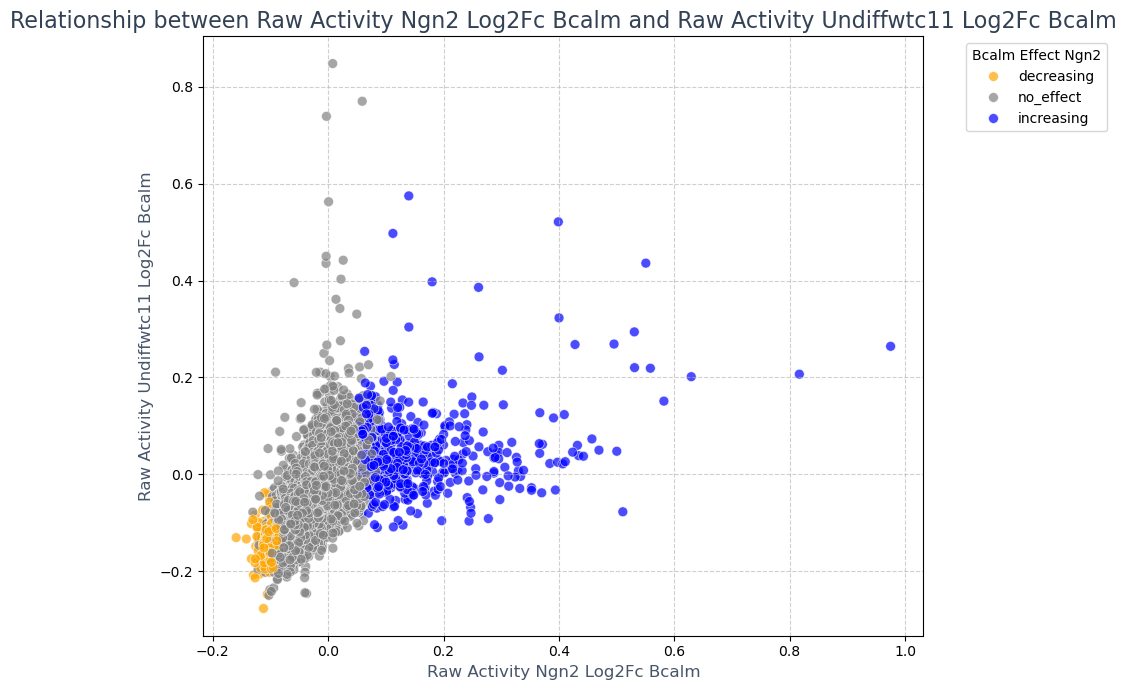

In [32]:
import pandas as pd
import numpy as np
import seaborn as sns

def plot_scatter(df, x_col, y_col, color_col):
    """
    Creates a customizable scatter plot using Seaborn and Matplotlib.

    Args:
        df (pd.DataFrame): The input DataFrame containing the data.
        x_col (str): The column name for the X-axis.
        y_col (str): The column name for the Y-axis.
        color_col (str): The column name to use for coloring the points.

    Returns:
        None: Displays the plot using Matplotlib.
    """
    # Define colors for the effect categories
    color_palette = {
        "no_effect": "gray",
        "increasing": "blue",
        "decreasing": "orange"
    }

    plt.figure(figsize=(10, 7)) # Set figure size for better readability
    sns.scatterplot(
        data=df,
        x=x_col,
        y=y_col,
        hue=color_col, # Use hue for coloring by category
        palette=color_palette,
        s=50, # Marker size
        alpha=0.7, # Transparency
        edgecolor='w', # White edge for markers
        linewidth=0.5
    )

    plt.title(f"Relationship between {x_col.replace('_', ' ').title()} and {y_col.replace('_', ' ').title()}",
              fontsize=16, color='#334155')
    plt.xlabel(x_col.replace('_', ' ').title(), fontsize=12, color='#475569')
    plt.ylabel(y_col.replace('_', ' ').title(), fontsize=12, color='#475569')
    plt.legend(title=color_col.replace('_', ' ').title(), bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()


# 2. Define default columns
x_column_name = 'raw_activity_NGN2_log2FC_bcalm'
y_column_name = 'raw_activity_undiffWTC11_log2FC_bcalm'
default_color = 'bcalm_effect_NGN2'

# 3. Create and display the plot with default columns
print(f"\nPlotting with X='{x_column_name}', Y='{y_column_name}', Color='{default_color}'")
plot_scatter(df_elements_no_alt_measured_in_both, x_column_name, y_column_name, default_color)


# Example of a customized plot:
# plot_scatter(df, 'normalized_activity_NGN2', 'normalized_activity_undiffWTC11', 'bcalm_effect_undiffWTC11')

##### Groups between both cell-types

Raw logFC


Plotting with X='raw_activity_NGN2_log2FC_bcalm', Y='raw_activity_undiffWTC11_log2FC_bcalm', Color='combined_effect_type'


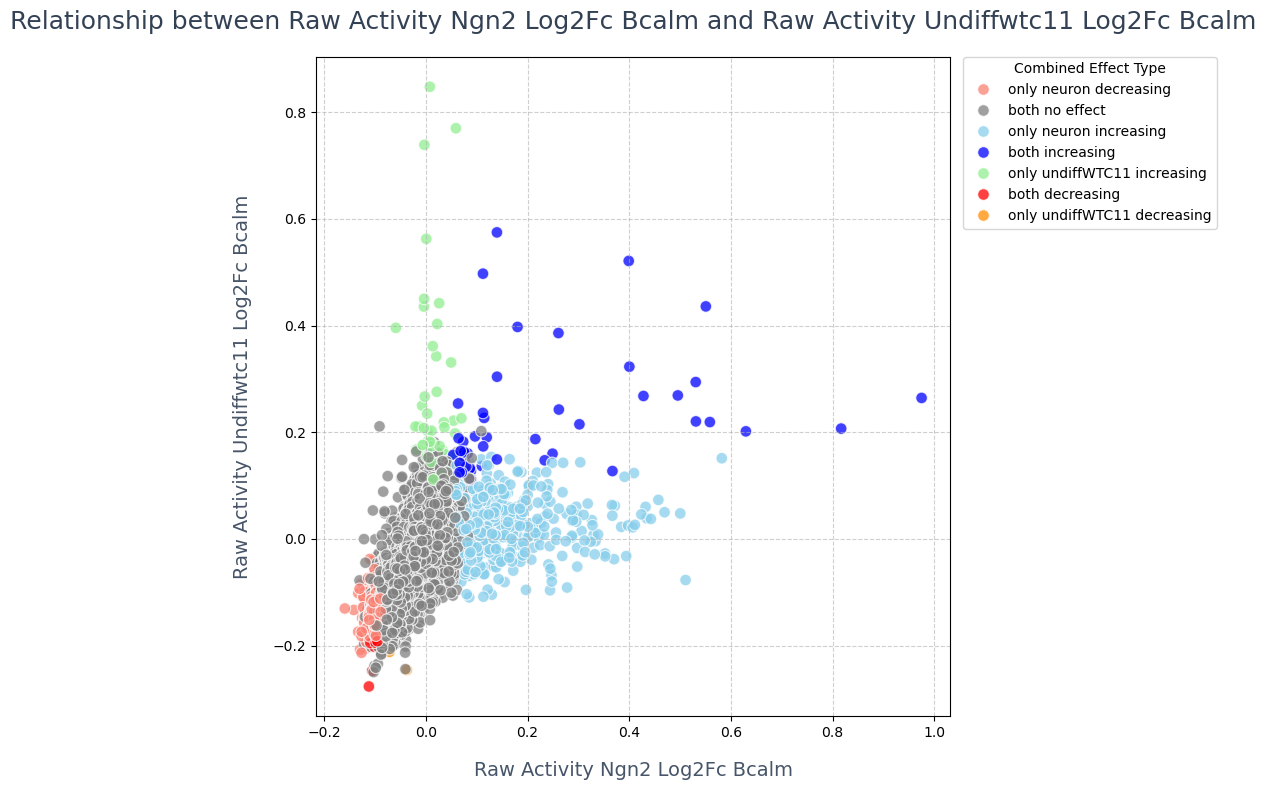

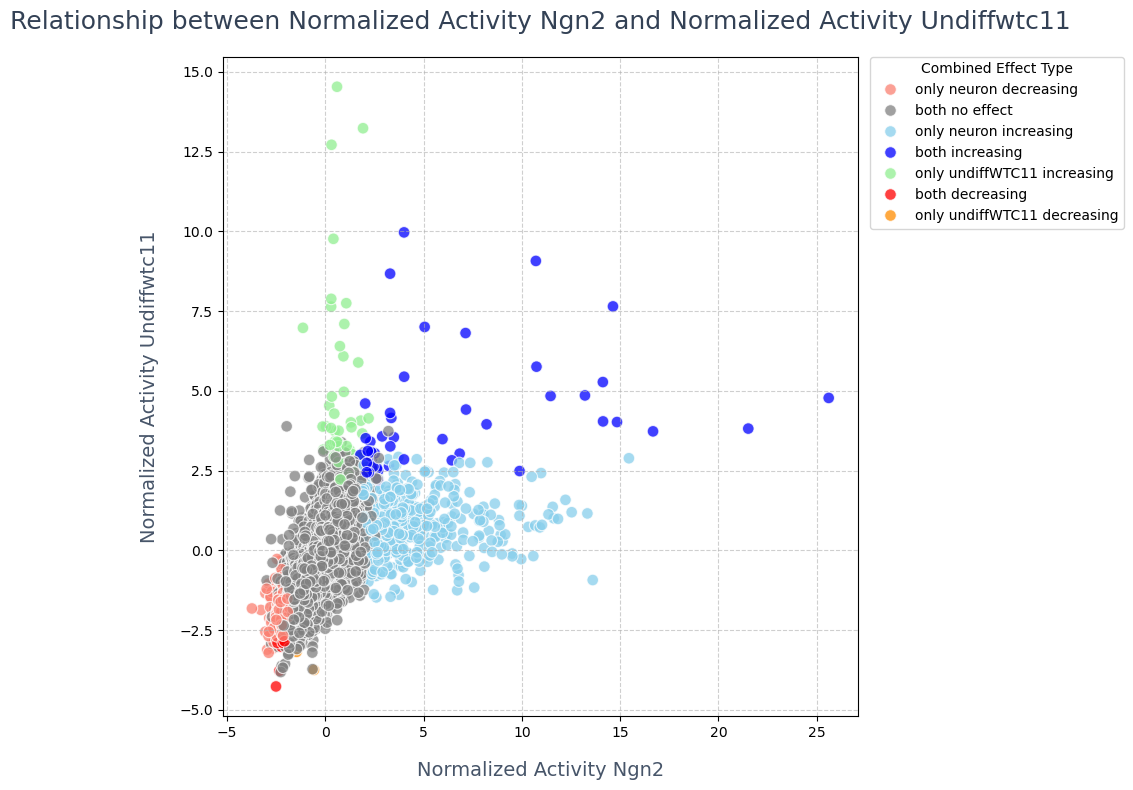

In [37]:
def add_combined_effect_column(df):
    """
    Adds a 'combined_effect_type' column to the DataFrame based on
    bcalm_effect_NGN2 and bcalm_effect_undiffWTC11.
    """
    def get_combined_effect(row):
        ngn2_effect = row['bcalm_effect_NGN2']
        undiff_effect = row['bcalm_effect_undiffWTC11']

        if ngn2_effect == 'increasing' and undiff_effect == 'increasing':
            return 'both increasing'
        elif ngn2_effect == 'decreasing' and undiff_effect == 'decreasing':
            return 'both decreasing'
        elif ngn2_effect == 'no_effect' and undiff_effect == 'no_effect':
            return 'both no effect'
        elif ngn2_effect == 'increasing' and undiff_effect != 'increasing':
            return 'only neuron increasing'
        elif undiff_effect == 'increasing' and ngn2_effect != 'increasing':
            return 'only undiffWTC11 increasing'
        elif ngn2_effect == 'decreasing' and undiff_effect != 'decreasing':
            return 'only neuron decreasing'
        elif undiff_effect == 'decreasing' and ngn2_effect != 'decreasing':
            return 'only undiffWTC11 decreasing'
        else:
            return 'mixed effect' # Catches all other combinations

    df['combined_effect_type'] = df.apply(get_combined_effect, axis=1)
    return df

def plot_scatter(df, x_col, y_col, color_col):
    """
    Creates a customizable scatter plot using Seaborn and Matplotlib.

    Args:
        df (pd.DataFrame): The input DataFrame containing the data.
        x_col (str): The column name for the X-axis.
        y_col (str): The column name for the Y-axis.
        color_col (str): The column name to use for coloring the points.

    Returns:
        None: Displays the plot using Matplotlib.
    """
    # Define colors for the effect categories
    # Adjusted palette to include new combined effect types
    color_palette = {
        "both increasing": "blue",
        "both decreasing": "red",
        "both no effect": "gray",
        "only neuron increasing": "skyblue",
        "only undiffWTC11 increasing": "lightgreen",
        "only neuron decreasing": "salmon",
        "only undiffWTC11 decreasing": "darkorange", # Changed from lightcoral to darkorange
        "mixed effect": "purple"
    }

    plt.figure(figsize=(12, 8)) # Set figure size for better readability
    sns.scatterplot(
        data=df,
        x=x_col,
        y=y_col,
        hue=color_col, # Use hue for coloring by category
        palette=color_palette,
        s=70, # Marker size increased for visibility
        alpha=0.75, # Transparency adjusted
        edgecolor='w', # White edge for markers
        linewidth=0.8
    )

    plt.title(f"Relationship between {x_col.replace('_', ' ').title()} and {y_col.replace('_', ' ').title()}",
              fontsize=18, color='#334155', pad=20)
    plt.xlabel(x_col.replace('_', ' ').title(), fontsize=14, color='#475569', labelpad=15)
    plt.ylabel(y_col.replace('_', ' ').title(), fontsize=14, color='#475569', labelpad=15)
    plt.legend(title=color_col.replace('_', ' ').title(), bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to prevent legend from overlapping
    plt.show()


# 2. Add the new combined effect column
df_elements_no_alt_measured_in_both = add_combined_effect_column(df_elements_no_alt_measured_in_both)

# 3. Define default columns, now using the new combined effect column
x_column_name = 'raw_activity_NGN2_log2FC_bcalm'
y_column_name = 'raw_activity_undiffWTC11_log2FC_bcalm'
default_color = 'combined_effect_type' # Use the new combined effect column

# 4. Create and display the plot with default columns
print(f"\nPlotting with X='{x_column_name}', Y='{y_column_name}', Color='{default_color}'")
plot_scatter(df_elements_no_alt_measured_in_both, x_column_name, y_column_name, default_color)

x_column_name = 'normalized_activity_NGN2'
y_column_name = 'normalized_activity_undiffWTC11'
plot_scatter(df_elements_no_alt_measured_in_both, x_column_name, y_column_name, default_color)



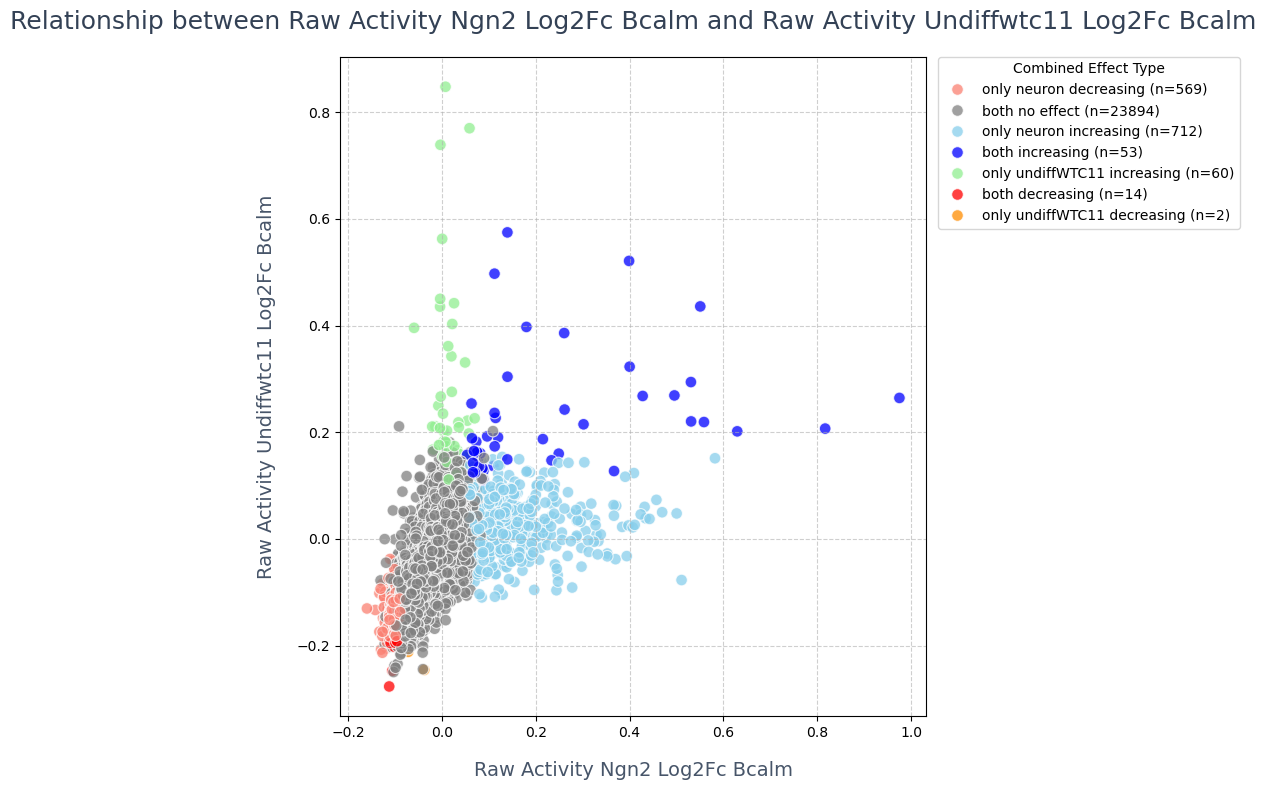

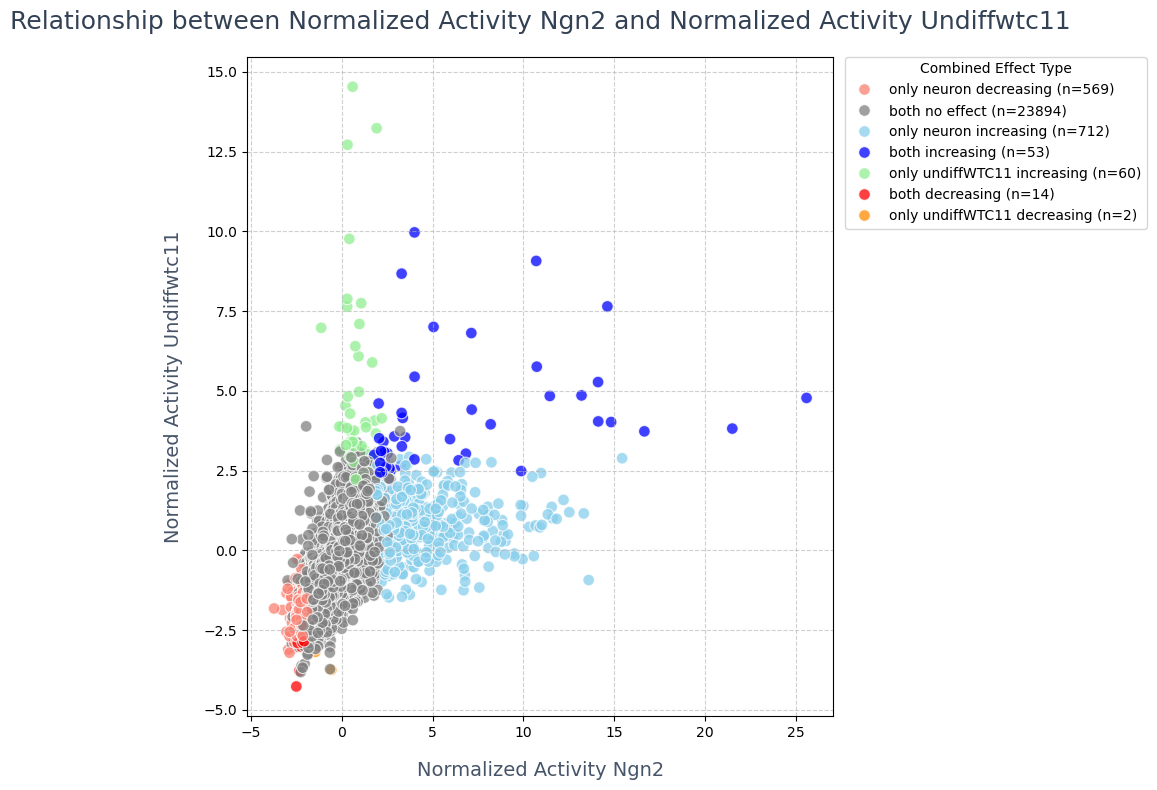

In [38]:
def plot_scatter(df, x_col, y_col, color_col):
    """
    Creates a customizable scatter plot using Seaborn and Matplotlib.

    Args:
        df (pd.DataFrame): The input DataFrame containing the data.
        x_col (str): The column name for the X-axis.
        y_col (str): The column name for the Y-axis.
        color_col (str): The column name to use for coloring the points.

    Returns:
        None: Displays the plot using Matplotlib.
    """
    # Define colors for the effect categories
    # Adjusted palette to include new combined effect types
    color_palette = {
        "both increasing": "blue",
        "both decreasing": "red",
        "both no effect": "gray",
        "only neuron increasing": "skyblue",
        "only undiffWTC11 increasing": "lightgreen",
        "only neuron decreasing": "salmon",
        "only undiffWTC11 decreasing": "darkorange", # Changed from lightcoral to darkorange
        "mixed effect": "purple"
    }

    plt.figure(figsize=(12, 8)) # Set figure size for better readability
    sns.scatterplot(
        data=df,
        x=x_col,
        y=y_col,
        hue=color_col, # Use hue for coloring by category
        palette=color_palette,
        s=70, # Marker size increased for visibility
        alpha=0.75, # Transparency adjusted
        edgecolor='w', # White edge for markers
        linewidth=0.8
    )

    plt.title(f"Relationship between {x_col.replace('_', ' ').title()} and {y_col.replace('_', ' ').title()}",
              fontsize=18, color='#334155', pad=20)
    plt.xlabel(x_col.replace('_', ' ').title(), fontsize=14, color='#475569', labelpad=15)
    plt.ylabel(y_col.replace('_', ' ').title(), fontsize=14, color='#475569', labelpad=15)

    # Calculate group sizes for the legend
    group_sizes = df[color_col].value_counts().to_dict()

    # Get current legend handles and labels
    handles, labels = plt.gca().get_legend_handles_labels()

    # Update labels with group sizes
    updated_labels = []
    # The first label is typically the hue title, skip it or handle it if necessary
    # Assuming the order of labels matches the order of categories in the palette/hue
    for label in labels:
        if label in group_sizes:
            updated_labels.append(f"{label} (n={group_sizes[label]})")
        else:
            # This handles the legend title if it's included in labels
            updated_labels.append(label)

    # Re-create the legend with updated labels
    plt.legend(handles, updated_labels, title=color_col.replace('_', ' ').title(), bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to prevent legend from overlapping
    plt.show()
x_column_name = 'raw_activity_NGN2_log2FC_bcalm'
y_column_name = 'raw_activity_undiffWTC11_log2FC_bcalm'
plot_scatter(df_elements_no_alt_measured_in_both, x_column_name, y_column_name, default_color)

x_column_name = 'normalized_activity_NGN2'
y_column_name = 'normalized_activity_undiffWTC11'
plot_scatter(df_elements_no_alt_measured_in_both, x_column_name, y_column_name, default_color)


#### Check for the overlap of the measured sequences in both cell-types

/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth

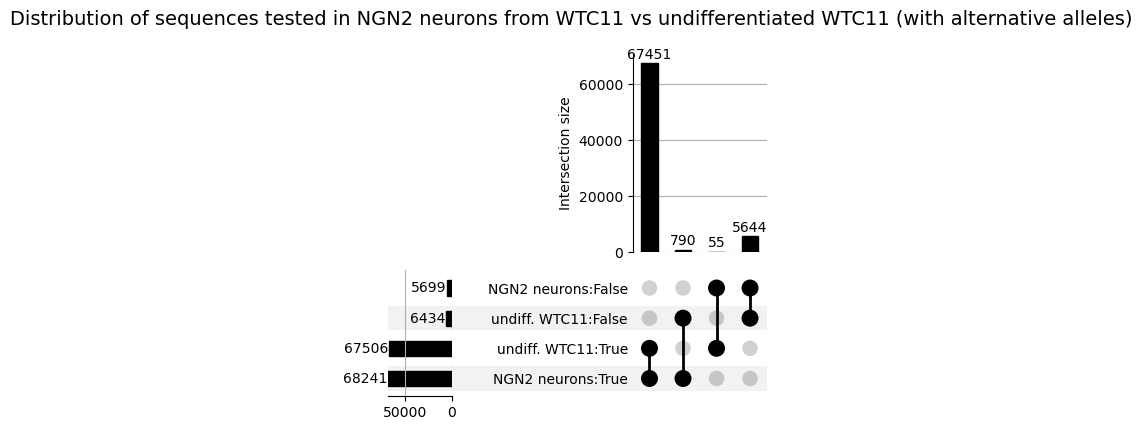

In [14]:
from upsetplot import from_memberships, UpSet
import matplotlib.pyplot as plt
# Create a combined membership list for each row
memberships = df_elements_all_regions.apply(lambda row: (f"NGN2 neurons:{row['bcalm_data_exists_NGN2']}", f"undiff. WTC11:{row['bcalm_data_exists_undiffWTC11']}"), axis=1)

# Step 2: Count how many times each membership combination occurs
membership_counts = memberships.value_counts()

# Count occurrences of each unique combination
data = from_memberships(membership_counts.index, data=membership_counts.values)


# Plot the UpSet
upset = UpSet(data, show_counts=True)
upset.plot()
plt.suptitle("Distribution of sequences tested in NGN2 neurons from WTC11 vs undifferentiated WTC11 (with alternative alleles)", fontsize=14)
plt.tight_layout()
plt.show()

/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth

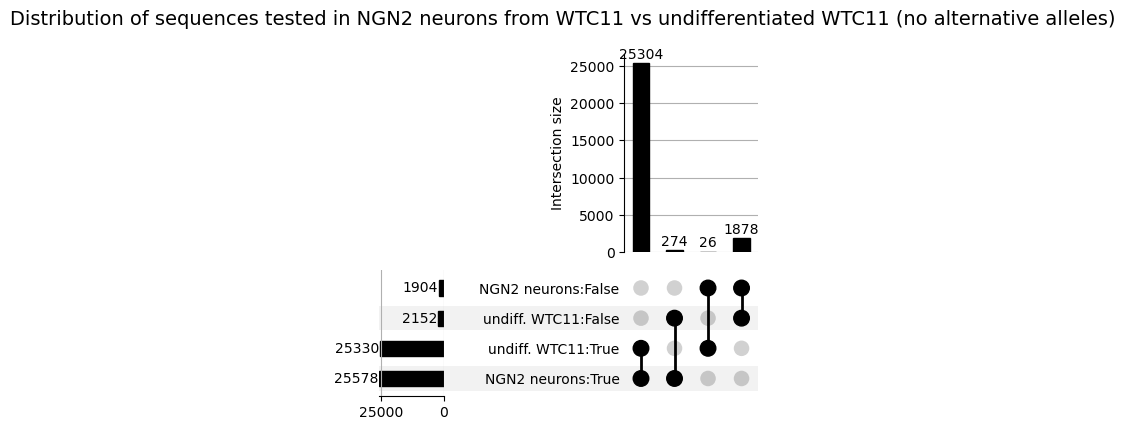

In [15]:
from upsetplot import from_memberships, UpSet
import matplotlib.pyplot as plt
# Create a combined membership list for each row
memberships = df_elements_no_alt.apply(lambda row: (f"NGN2 neurons:{row['bcalm_data_exists_NGN2']}", f"undiff. WTC11:{row['bcalm_data_exists_undiffWTC11']}"), axis=1)

# Step 2: Count how many times each membership combination occurs
membership_counts = memberships.value_counts()

# Count occurrences of each unique combination
data = from_memberships(membership_counts.index, data=membership_counts.values)


# Plot the UpSet
upset = UpSet(data, show_counts=True)
upset.plot()
plt.suptitle("Distribution of sequences tested in NGN2 neurons from WTC11 vs undifferentiated WTC11 (no alternative alleles)", fontsize=14)
plt.tight_layout()
plt.show()

### Get the dCREs:

#### Check for overlaps in the bed:

In [ ]:
# check for an overlap of defined regions (chr, start, end, strand) within the dataframe
df_elements_no_alt['region_definition'] = df_elements_no_alt[[col_chr, col_start, col_end]].astype(str).agg('-'.join, axis=1)
df_elements_no_alt

if df_elements_no_alt['region_definition'].duplicated().any():
    print("There are duplicated region definitions in the dataframe.")
    duplicated_regions = df_elements_no_alt[df_elements_no_alt['region_definition'].duplicated(keep=False)] # 546 duplicated rows => 273
    print(duplicated_regions)
else:
    print("No duplicated region definitions found in the dataframe.")

#### NGN2: two bed files

In [16]:
df_elements_no_alt

,name,chr,start,end,strand,sequence,label,raw_activity_NGN2_log2FC_bcalm,bcalm_adj_p_NGN2,normalized_activity_NGN2,...,SCREEN_ID,is_NPC_SCREEN_cCRE,is_WTC11_SCREEN_cCRE,is_H9_SCREEN_cCRE,is_H1_SCREEN_cCRE,is_dCRE_NGN2,is_dCRE_undiffWTC11,bcalm_effect_NGN2,bcalm_effect_undiffWTC11,measured_in_both_celltypes
0,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70276484,70276754,-,CTTGAATTTGAATTTAGAGTGAACATGTTGTGATTTTGTATCTGTG...,tested,-0.089726,2.492488e-03,-1.928542,...,EH38E1825144,False,False,False,False,True,False,decreasing,no_effect,True
1,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70323127,70323397,-,GCAGTGGCTCATGCCTGCAATCTCAGCACTTCGGGAGGTTGAGGTG...,tested,-0.026591,1.000000e+00,-0.295843,...,EH38E1825170,False,False,False,False,False,False,no_effect,no_effect,True
2,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70325057,70325327,-,GCAAGGATCTAAAGTTCCAATTGGCATTAGCTTTCTTTTCGTTTAC...,tested,-0.033114,1.000000e+00,-0.464529,...,EH38E1825171,False,False,False,False,False,False,no_effect,no_effect,True
3,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70213614,70213884,-,TTTTTTCAGGAAGTGAAGAATTTAGAGGGATAAAAGGCGGAAATAA...,tested,-0.018290,1.000000e+00,-0.081174,...,EH38E3188739,False,False,False,False,False,False,no_effect,no_effect,True
4,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70277149,70277419,-,ATCTGGCAGGCCTTTCCCCTCTGCAGGTGGTGTCACTCGTGGTGGT...,tested,-0.038026,1.000000e+00,-0.591552,...,EH38E3188758,False,False,False,False,False,False,no_effect,no_effect,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73935,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,106984308,106984578,+,TAGAAAAGCACAATGAACTGAAACCTTACAAATGCCAGCTCTGCTA...,tested,-0.076844,1.000000e+00,-1.595406,...,EH38E3899597,False,False,False,False,False,False,no_effect,no_effect,True
73936,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107008116,107008386,+,AAGCAGAATCCTCCCCACCCCCCTCTCATTATGCAGTTGGGGAGGA...,tested,0.138223,8.599369e-22,3.966275,...,EH38E3899600,False,False,False,False,True,False,increasing,no_effect,True
73937,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107019262,107019532,+,GAAGAGGTCCCCTGGGTCTGAAAATTATAATAGACGGCAGCAGTGA...,tested,0.054619,3.581264e-01,1.804262,...,EH38E3899604,False,False,False,False,False,False,no_effect,no_effect,True
73938,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107038939,107039209,+,CTGTCTTCAAGCATCCTAAATCTTTTATATGAGTGTCTCTAGAAGG...,tested,-0.064615,1.000000e+00,-1.279153,...,EH38E3899614,False,False,False,False,False,False,no_effect,no_effect,True


In [ ]:
output_path = "/home/kisa/coding/80K_MPRA/remap_chipseq_pia/"
# make start and end into integers

ngn2_increasing_elements = df_elements_no_alt.loc[df_elements_no_alt['bcalm_effect_NGN2'] == 'increasing'].copy()
ngn2_decreasing_elements = df_elements_no_alt.loc[df_elements_no_alt['bcalm_effect_NGN2'] == 'decreasing'].copy()

ngn2_increasing_elements['score'] = 1
ngn2_decreasing_elements['score'] = 1

In [ ]:
# how many sequences are duplicated?
ngn2_increasing_elements

if ngn2_increasing_elements['region_definition'].duplicated().any():
    print("There are duplicated region definitions in the dataframe.")
    duplicated_regions = ngn2_increasing_elements[ngn2_increasing_elements['region_definition'].duplicated(keep=False)] # one region: dCRE in NGN2 neurons no effect in undiff WTC11
    print(duplicated_regions)
    print(duplicated_regions['name'].to_list())
else:
    print("No duplicated region definitions found in the dataframe.")

There are duplicated region definitions in the dataframe.
                                                    name    chr      start  \
49919  cardiac_neuro_cava_random:HECTD4|ENSG000001730...  chr12  112386316   
52614  cardiac_neuro_cava_random:PTPN11|ENSG000001792...  chr12  112386316   

             end strand                                           sequence  \
49919  112386586      -  TGTGTGTTGTCTAGACTAGATACAGATTCTCTTCCTCGTAGCTTCC...   
52614  112386586      +  GATCTAGGGCTTAAAGTCTTTAGACTGCATAATGAATAGTTATTTA...   

        label  raw_activity_NGN2_log2FC_bcalm  bcalm_adj_p_NGN2  \
49919  tested                        0.085518      4.949451e-11   
52614  tested                        0.163837      1.120613e-24   

       normalized_activity_NGN2  ...  is_WTC11_SCREEN_cCRE  is_H9_SCREEN_cCRE  \
49919                  2.603318  ...                 False              False   
52614                  4.628677  ...                 False              False   

       is_H1_SCREEN_cCRE  

In [ ]:
# how many sequences are duplicated? No duplicated regions in the decreasing elements
ngn2_decreasing_elements

if ngn2_decreasing_elements['region_definition'].duplicated().any():
    print("There are duplicated region definitions in the dataframe.")
    duplicated_regions = ngn2_decreasing_elements[ngn2_decreasing_elements['region_definition'].duplicated(keep=False)] # one region: dCRE in NGN2 neurons no effect in undiff WTC11
    print(duplicated_regions)
    print(duplicated_regions['name'].to_list())
else:
    print("No duplicated region definitions found in the dataframe.")

No duplicated region definitions found in the dataframe.


In [ ]:
# write as bed file
writing = False
if writing:
    output_file_ngn2_increasing = os.path.join(output_path, "ngn2_increasing_regions_duplicates_without_considering_strand.bed")
    ngn2_increasing_elements[[col_chr, col_start, col_end, col_name, col_strand, "score"]].to_csv(output_file_ngn2_increasing, sep='\t', index=False, header=False)
    output_file_ngn2_decreasing = os.path.join(output_path, "ngn2_decreasing_regions_duplicates_without_considering_strand.bed")
    ngn2_decreasing_elements[[col_chr, col_start, col_end, col_name, col_strand, "score"]].to_csv(output_file_ngn2_decreasing, sep='\t', index=False, header=False)
    print(f"NGN2 increasing regions written to {output_file_ngn2_increasing}")
    print(f"NGN2 decreasing regions written to {output_file_ngn2_decreasing}")


NGN2 increasing regions written to /home/kisa/coding/80K_MPRA/remap_chipseq_pia/80k_results/ngn2_increasing_regions_duplicates_without_considering_strand.bed
NGN2 decreasing regions written to /home/kisa/coding/80K_MPRA/remap_chipseq_pia/80k_results/ngn2_decreasing_regions_duplicates_without_considering_strand.bed


#### Write fasta files for HOMER

In [ ]:
output_file_ngn2_increasing = os.path.join(output_path, "ngn2_increasing_regions_duplicates_without_considering_strand.fa")
hf.write_fasta(ngn2_increasing_elements, output_file_ngn2_increasing, header=[col_name, col_sequence])
output_file_ngn2_decreasing = os.path.join(output_path, "ngn2_decreasing_regions_duplicates_without_considering_strand.fa")
hf.write_fasta(ngn2_decreasing_elements, output_file_ngn2_decreasing, header=[col_name, col_sequence])

True

In [ ]:
output_file_ngn2_increasing

'/home/kisa/coding/80K_MPRA/remap_chipseq_pia/ngn2_increasing_regions_duplicates_without_considering_strand.fa'

In [ ]:
output_file_ngn2_decreasing

'/home/kisa/coding/80K_MPRA/remap_chipseq_pia/ngn2_decreasing_regions_duplicates_without_considering_strand.fa'

### Get the dCREs in undiffWTC11: two bed files

In [19]:
output_path = "/home/kisa/coding/80K_MPRA/remap_chipseq_pia/"
# make start and end into integers

undiffWTC11_increasing_elements = df_elements_no_alt.loc[df_elements_no_alt['bcalm_effect_undiffWTC11'] == 'increasing'].copy()
undiffWTC11_decreasing_elements = df_elements_no_alt.loc[df_elements_no_alt['bcalm_effect_undiffWTC11'] == 'decreasing'].copy()

undiffWTC11_increasing_elements['score'] = 1
undiffWTC11_decreasing_elements['score'] = 1

In [22]:
# how many sequences are duplicated?
undiffWTC11_increasing_elements

if undiffWTC11_increasing_elements['region_definition'].duplicated().any():
    print("There are duplicated region definitions in the dataframe.")
    duplicated_regions = undiffWTC11_increasing_elements[undiffWTC11_increasing_elements['region_definition'].duplicated(keep=False)] # one region: dCRE in NGN2 neurons no effect in undiff WTC11
    print(duplicated_regions)
    print(duplicated_regions['name'].to_list())
else:
    print("No duplicated region definitions found in the dataframe.")

No duplicated region definitions found in the dataframe.


In [25]:
# write as bed file
writing = False
if writing:
    output_file_undiffWTC11_increasing = os.path.join(output_path, "undiffWTC11_increasing_regions_no_duplicates.bed")
    undiffWTC11_increasing_elements[[col_chr, col_start, col_end, col_name, col_strand, "score"]].to_csv(output_file_undiffWTC11_increasing, sep='\t', index=False, header=False)
    output_file_undiffWTC11_decreasing = os.path.join(output_path, "undiffWTC11_decreasing_regions_no_duplicates.bed")
    undiffWTC11_decreasing_elements[[col_chr, col_start, col_end, col_name, col_strand, "score"]].to_csv(output_file_undiffWTC11_decreasing, sep='\t', index=False, header=False)
    print(f"NGN2 increasing regions written to {output_file_undiffWTC11_increasing}")
    print(f"NGN2 decreasing regions written to {output_file_undiffWTC11_decreasing}")


NGN2 increasing regions written to /home/kisa/coding/80K_MPRA/remap_chipseq_pia/undiffWTC11_increasing_regions_no_duplicates.bed
NGN2 decreasing regions written to /home/kisa/coding/80K_MPRA/remap_chipseq_pia/undiffWTC11_decreasing_regions_no_duplicates.bed


### Identify the sequences which have activity close to zero within both cell-types
- Get the information about the IQR differences between the two cell-types: 
WTC11 IQR: 0.096004178411475, upper threshold: 0.1655261151498412, lower threshold: -0.21849059849605879
NGN2 IQR: 0.05458866274311965, upper threshold: 0.08948167623965607, lower threshold: -0.12887297473282253
=> 0.096004178411475 / 0.05458866274311965
1.7586834625945358 ~ 1.75868
IQR of WTC11 is 1.76 times larger than the IQR of NGN2 => threshold for undiff. WTC11 should be 1.76 times larger than the threshold for NGN2 

- tested different thresholds for the distance to zero: 
- 0.5, 

In [ ]:
def activity_is_close_to_zero(activity, zero_distance):
    """
    Check if the activity is close to zero within a specified distance.
    """
    return abs(activity) < zero_distance

# for ngn2 and undiff wtc11: check if the activity given by a column name is close to zero
def check_activity_close_to_zero(df, column_name, zero_distance):
    """
    Check if the activity in the specified column is close to zero within a specified distance.
    """
    return df[column_name].apply(lambda x: activity_is_close_to_zero(x, zero_distance))



In [ ]:
ngn2_zero_distance = 0.5
df_elements_no_alt['ngn2_zero_activity'] = check_activity_close_to_zero(df_elements_no_alt, 'raw_activity_NGN2_log2FC_bcalm', ngn2_zero_distance)
undiff_wtc11_zero_distance = ngn2_zero_distance * 1.75868
df_elements_no_alt['undiff_wtc11_zero_activity'] = check_activity_close_to_zero(df_elements_no_alt, 'raw_activity_undiffWTC11_log2FC_bcalm', undiff_wtc11_zero_distance)
df_elements_no_alt['ngn2_zero_activity'].value_counts()

ngn2_zero_activity
True     25568
False     1914
Name: count, dtype: int64

In [ ]:
df_elements_no_alt['undiff_wtc11_zero_activity'].value_counts()

undiff_wtc11_zero_activity
True     25330
False     2152
Name: count, dtype: int64

In [ ]:
ngn2_zero_distance = 0.1
df_elements_no_alt['ngn2_zero_activity'] = check_activity_close_to_zero(df_elements_no_alt, 'raw_activity_NGN2_log2FC_bcalm', ngn2_zero_distance)
undiff_wtc11_zero_distance = ngn2_zero_distance * 1.75868
df_elements_no_alt['undiff_wtc11_zero_activity'] = check_activity_close_to_zero(df_elements_no_alt, 'raw_activity_undiffWTC11_log2FC_bcalm', undiff_wtc11_zero_distance)
df_elements_no_alt['ngn2_zero_activity'].value_counts()

ngn2_zero_activity
True     24962
False     2520
Name: count, dtype: int64

In [ ]:
df_elements_no_alt['undiff_wtc11_zero_activity'].value_counts()

undiff_wtc11_zero_activity
True     25178
False     2304
Name: count, dtype: int64

In [ ]:
ngn2_zero_distance = 0.08
df_elements_no_alt['ngn2_zero_activity'] = check_activity_close_to_zero(df_elements_no_alt, 'raw_activity_NGN2_log2FC_bcalm', ngn2_zero_distance)
undiff_wtc11_zero_distance = ngn2_zero_distance * 1.75868
df_elements_no_alt['undiff_wtc11_zero_activity'] = check_activity_close_to_zero(df_elements_no_alt, 'raw_activity_undiffWTC11_log2FC_bcalm', undiff_wtc11_zero_distance)
df_elements_no_alt['ngn2_zero_activity'].value_counts()

ngn2_zero_activity
True     23597
False     3885
Name: count, dtype: int64

In [ ]:
df_elements_no_alt['undiff_wtc11_zero_activity'].value_counts()

undiff_wtc11_zero_activity
True     24586
False     2896
Name: count, dtype: int64

In [ ]:
ngn2_zero_distance = 0.05 # 7 still overlapping
df_elements_no_alt['ngn2_zero_activity'] = check_activity_close_to_zero(df_elements_no_alt, 'raw_activity_NGN2_log2FC_bcalm', ngn2_zero_distance)
undiff_wtc11_zero_distance = ngn2_zero_distance * 1.75868
df_elements_no_alt['undiff_wtc11_zero_activity'] = check_activity_close_to_zero(df_elements_no_alt, 'raw_activity_undiffWTC11_log2FC_bcalm', undiff_wtc11_zero_distance)
df_elements_no_alt['ngn2_zero_activity'].value_counts()

ngn2_zero_activity
True     19640
False     7842
Name: count, dtype: int64

In [ ]:
df_elements_no_alt['undiff_wtc11_zero_activity'].value_counts()

undiff_wtc11_zero_activity
True     20827
False     6655
Name: count, dtype: int64

In [ ]:
ngn2_zero_distance = 0.04 # 0 overlapping
df_elements_no_alt['ngn2_zero_activity'] = check_activity_close_to_zero(df_elements_no_alt, 'raw_activity_NGN2_log2FC_bcalm', ngn2_zero_distance)
undiff_wtc11_zero_distance = ngn2_zero_distance * 1.75868
df_elements_no_alt['undiff_wtc11_zero_activity'] = check_activity_close_to_zero(df_elements_no_alt, 'raw_activity_undiffWTC11_log2FC_bcalm', undiff_wtc11_zero_distance)
df_elements_no_alt['ngn2_zero_activity'].value_counts()

ngn2_zero_activity
True     17708
False     9774
Name: count, dtype: int64

In [ ]:
df_elements_no_alt['undiff_wtc11_zero_activity'].value_counts()

undiff_wtc11_zero_activity
True     18596
False     8886
Name: count, dtype: int64

In [ ]:
ngn2_zero_distance = 0.01 # still no overlapping
df_elements_no_alt['ngn2_zero_activity'] = check_activity_close_to_zero(df_elements_no_alt, 'raw_activity_NGN2_log2FC_bcalm', ngn2_zero_distance)
undiff_wtc11_zero_distance = ngn2_zero_distance * 1.75868
df_elements_no_alt['undiff_wtc11_zero_activity'] = check_activity_close_to_zero(df_elements_no_alt, 'raw_activity_undiffWTC11_log2FC_bcalm', undiff_wtc11_zero_distance)
df_elements_no_alt['ngn2_zero_activity'].value_counts()

ngn2_zero_activity
False    21034
True      6448
Name: count, dtype: int64

In [ ]:
# df_elements_no_alt['undiff_wtc11_zero_activity'].value_counts()

undiff_wtc11_zero_activity
False    21488
True      5994
Name: count, dtype: int64

/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth

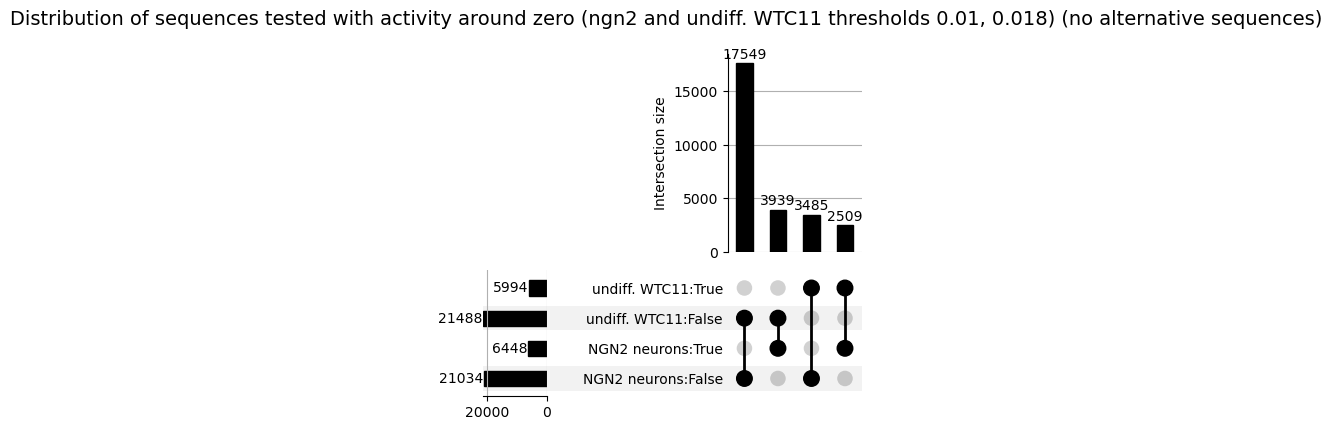

In [ ]:
from upsetplot import from_memberships, UpSet
import matplotlib.pyplot as plt
# Create a combined membership list for each row
memberships = df_elements_no_alt.apply(lambda row: (f"NGN2 neurons:{row['ngn2_zero_activity']}", f"undiff. WTC11:{row['undiff_wtc11_zero_activity']}"), axis=1)

# Step 2: Count how many times each membership combination occurs
membership_counts = memberships.value_counts()

# Count occurrences of each unique combination
data = from_memberships(membership_counts.index, data=membership_counts.values)


# Plot the UpSet
upset = UpSet(data, show_counts=True, sort_categories_by=None)
upset.plot()
plt.suptitle(f"Distribution of sequences tested with activity around zero (ngn2 and undiff. WTC11 thresholds {ngn2_zero_distance}, {round(undiff_wtc11_zero_distance,3)}) (no alternative sequences)", fontsize=14)
plt.tight_layout()
plt.show()

#### Take the 0.01 threshold for NGN2 and the respective threshold for undiff. WTC11

In [ ]:
df_elements_no_alt_zero_activity_both_cell_types = df_elements_no_alt.loc[df_elements_no_alt['ngn2_zero_activity'] & df_elements_no_alt['undiff_wtc11_zero_activity']].copy()

df_elements_no_alt_zero_activity_both_cell_types

,name,chr,start,end,strand,sequence,label,raw_activity_NGN2_log2FC_bcalm,bcalm_adj_p_NGN2,normalized_activity_NGN2,...,is_H9_SCREEN_cCRE,is_H1_SCREEN_cCRE,is_dCRE_NGN2,is_dCRE_undiffWTC11,bcalm_effect_NGN2,bcalm_effect_undiffWTC11,measured_in_both_celltypes,region_definition,ngn2_zero_activity,undiff_wtc11_zero_activity
13,cardiac_neuro_cava_random:ABCC9|ENSG0000006943...,chr12,21883209,21883479,-,GGGAGGCCTCACAAACATGGTGGAAGGCAAAGGAGAAGCAAAGGCA...,tested,0.001169,1.0,0.422042,...,False,False,False,False,no_effect,no_effect,True,chr12-21883209-21883479,True,True
17,cardiac_neuro_cava_random:ABL1|ENSG00000097007...,chr9,130730253,130730523,+,CTGGTCTCGAACGCCCAACCTCAGGTGATCCGCCCACCTCGGCCTC...,tested,-0.007573,1.0,0.195973,...,False,False,False,False,no_effect,no_effect,True,chr9-130730253-130730523,True,True
61,cardiac_neuro_cava_random:ACTN2|ENSG0000007752...,chr1,236701860,236702130,+,AATAGAACAAGTTCCCTCATTTCTATAATGAGACACAGGTAGGGCT...,tested,-0.004909,1.0,0.264866,...,False,False,False,False,no_effect,no_effect,True,chr1-236701860-236702130,True,True
63,cardiac_neuro_cava_random:ACTN2|ENSG0000007752...,chr1,236724994,236725264,+,AACCAGATGAATGACAGATTAGTTGTCATCAACTACACACAGTTTA...,tested,-0.006483,1.0,0.224157,...,False,False,False,False,no_effect,no_effect,True,chr1-236724994-236725264,True,True
74,cardiac_neuro_cava_random:ACVR1|ENSG0000011517...,chr2,157813494,157813764,-,GAACACAAAAGTTTATTTTTTCTTCACTTAACAGTCCCTGTGTAAG...,tested,-0.000836,1.0,0.370186,...,False,False,False,False,no_effect,no_effect,True,chr2-157813494-157813764,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73915,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,106962676,106962946,+,CAAGGTTTTGTTTTTACTCATCAGAATGACAGGAAGTTTTCAGTGT...,tested,-0.000671,1.0,0.374446,...,False,False,False,False,no_effect,no_effect,True,chr9-106962676-106962946,True,True
73922,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,106915876,106916146,+,TTAGGTAATCAGTTTTGTCTGCTATAAGAAAATAGACTGGAAGGGT...,tested,-0.000391,1.0,0.381685,...,False,False,False,False,no_effect,no_effect,True,chr9-106915876-106916146,True,True
73928,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,106947194,106947464,+,TTCAACCCAAAGGAAGTGTTTGGCTGAGAATTTAGGGCCCAGCTAA...,tested,0.002603,1.0,0.459114,...,False,False,False,False,no_effect,no_effect,True,chr9-106947194-106947464,True,True
73930,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,106957035,106957305,+,TTTCCTTTGCATTCACAACTTGACTAACTGTTTGGCACAAGAGGCC...,tested,-0.006705,1.0,0.218410,...,False,False,False,False,no_effect,no_effect,True,chr9-106957035-106957305,True,True


In [ ]:
if df_elements_no_alt_zero_activity_both_cell_types['region_definition'].duplicated().any():
    print("There are duplicated region definitions in the dataframe.")
    duplicated_regions = df_elements_no_alt_zero_activity_both_cell_types[df_elements_no_alt_zero_activity_both_cell_types['region_definition'].duplicated(keep=False)] # one region: dCRE in NGN2 neurons no effect in undiff WTC11
    print(duplicated_regions)
    print(duplicated_regions['name'].to_list())
else:
    print("No duplicated region definitions found in the dataframe.")

# 0.01 threshold: 4 rows => 2 regions are duplicated when we are not strand sensitive
# ['cardiac_neuro_cava_random:REF_CNOT3|ENSG00000088038.20|EH38E1963949_fwd_tile1-1', 'cardiac_neuro_cava_random:REF_MBOAT7|ENSG00000125505.17|EH38E1963949_rev_tile1-1', 'cardiac_neuro_cava_random:REF_RAI1|ENSG00000108557.20|EH38E3212346_fwd_tile1-1', 'cardiac_neuro_cava_random:REF_SREBF1|ENSG00000072310.18|EH38E3212346_rev_tile1-1']

# 0.04 threshold: 130 rows => 65 regions are duplicated when we are not strand sensitive


There are duplicated region definitions in the dataframe.
                                                    name    chr      start  \
49036  cardiac_neuro_cava_random:EMD|ENSG00000102119....   chrX  154383755   
49239  cardiac_neuro_cava_random:FLNA|ENSG00000196924...   chrX  154383755   
49890  cardiac_neuro_cava_random:HECTD4|ENSG000001730...  chr12  112370255   
49891  cardiac_neuro_cava_random:HECTD4|ENSG000001730...  chr12  112414283   
49920  cardiac_neuro_cava_random:HECTD4|ENSG000001730...  chr12  112419849   
...                                                  ...    ...        ...   
71588  cardiac_neuro_cava_random:RRAS|ENSG00000126458...  chr19   49627401   
72465  cardiac_neuro_cava_random:SREBF1|ENSG000000723...  chr17   17843140   
72466  cardiac_neuro_cava_random:SREBF1|ENSG000000723...  chr17   17850587   
72467  cardiac_neuro_cava_random:SREBF1|ENSG000000723...  chr17   17851683   
72468  cardiac_neuro_cava_random:SREBF1|ENSG000000723...  chr17   17857557   

     

In [ ]:
# write as bed file
writing = False
if writing:
    df_elements_no_alt_zero_activity_both_cell_types['score'] = 1
    output_file = os.path.join(output_path, f"around_zero_activity_both_cell_types_2_duplicated_regions_not_stand_aware_Thresh_004.bed")
    df_elements_no_alt_zero_activity_both_cell_types[[col_chr, col_start, col_end, col_name, col_strand, "score"]].to_csv(output_file, sep='\t', index=False, header=False)
    print(f"Written {output_file} with {len(df_elements_no_alt_zero_activity_both_cell_types)} regions.")

Written /home/kisa/coding/80K_MPRA/remap_chipseq_pia/80k_results/around_zero_activity_both_cell_types_2_duplicated_regions_not_stand_aware_Thresh_004.bed with 15823 regions.


In [ ]:
# write fasta file for homer
output_file = os.path.join(output_path, f"around_zero_activity_both_cell_types_thresh_001.fa")
hf.write_fasta(df_elements_no_alt_zero_activity_both_cell_types, output_file, header=[col_name, col_sequence])
print(f"Written {output_file} with {len(df_elements_no_alt_zero_activity_both_cell_types)} regions.")

Written /home/kisa/coding/80K_MPRA/remap_chipseq_pia/around_zero_activity_both_cell_types_thresh_001.fa with 2509 regions.


### Investigate if the dCREs are overlapping with the close to zero sequences

In [ ]:
df_elements_no_alt_zero_activity_both_cell_types.columns

Index(['name', 'chr', 'start', 'end', 'strand', 'sequence', 'label',
       'raw_activity_NGN2_log2FC_bcalm', 'bcalm_adj_p_NGN2',
       'normalized_activity_NGN2', 'bcalm_data_exists_NGN2',
       'raw_activity_undiffWTC11_log2FC_bcalm', 'bcalm_adj_p_undiffWTC11',
       'normalized_activity_undiffWTC11', 'bcalm_data_exists_undiffWTC11',
       'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_WTC11_SCREEN_cCRE',
       'is_H9_SCREEN_cCRE', 'is_H1_SCREEN_cCRE', 'is_dCRE_NGN2',
       'is_dCRE_undiffWTC11', 'bcalm_effect_NGN2', 'bcalm_effect_undiffWTC11',
       'measured_in_both_celltypes', 'region_definition', 'ngn2_zero_activity',
       'undiff_wtc11_zero_activity'],
      dtype='object')

In [ ]:
# both ngn2_zero_activity and undiff_wtc11_zero_activity are True for the whole dataframe

In [ ]:
df_elements_no_alt_zero_activity_both_cell_types.groupby(['ngn2_zero_activity', 'is_dCRE_NGN2']).size().unstack(fill_value=0)

is_dCRE_NGN2,False
ngn2_zero_activity,
True,15823


In [ ]:
df_elements_no_alt_zero_activity_both_cell_types.groupby(['undiff_wtc11_zero_activity', 'is_dCRE_undiffWTC11']).size().unstack(fill_value=0)

is_dCRE_undiffWTC11,False
undiff_wtc11_zero_activity,
True,15823


### Sanity checking the regions and if sampling is an option => reducing the number of sequences is highly recommended

In [ ]:
output_path = "/home/kisa/coding/80K_MPRA/remap_chipseq_pia/80k_results"

# read the background set
both_cell_types_background004 = os.path.join(output_path, f"around_zero_activity_both_cell_types_2_duplicated_regions_not_stand_aware_Thresh_001.bed")
both_cell_types_background001 = os.path.join(output_path, f"around_zero_activity_both_cell_types_2_duplicated_regions_not_stand_aware.bed")

# up and down regulating sequences
output_file_ngn2_increasing = os.path.join(output_path, "ngn2_increasing_regions_duplicates_without_considering_strand.bed")
output_file_ngn2_decreasing = os.path.join(output_path, "ngn2_decreasing_regions_duplicates_without_considering_strand.bed")

In [ ]:
increasing_bed = pd.read_csv(output_file_ngn2_increasing, sep='\t', header=None, names=[col_chr, col_start, col_end, col_name, col_strand, "score"])
decreasing_bed = pd.read_csv(output_file_ngn2_decreasing, sep='\t', header=None, names=[col_chr, col_start, col_end, col_name, col_strand, "score"])
background_bed = pd.read_csv(both_cell_types_background001, sep='\t', header=None, names=[col_chr, col_start, col_end, col_name, col_strand, "score"])


In [ ]:
increasing_bed

,chr,start,end,name,strand,score
0,chrX,148610380,148610650,cardiac_neuro_cava_random:AFF2|ENSG00000155966...,+,1
1,chrX,148714069,148714339,cardiac_neuro_cava_random:AFF2|ENSG00000155966...,+,1
2,chrX,148541408,148541678,cardiac_neuro_cava_random:AFF2|ENSG00000155966...,+,1
3,chr1,27577161,27577431,cardiac_neuro_cava_random:AHDC1|ENSG0000012670...,-,1
4,chr1,27593644,27593914,cardiac_neuro_cava_random:AHDC1|ENSG0000012670...,-,1
...,...,...,...,...,...,...
767,chr3,114714957,114715227,cardiac_neuro_cava_random:ZBTB20|ENSG000001817...,-,1
768,chr3,114498785,114499055,cardiac_neuro_cava_random:ZBTB20|ENSG000001817...,-,1
769,chr3,114812086,114812356,cardiac_neuro_cava_random:ZBTB20|ENSG000001817...,-,1
770,chr3,114899639,114899909,cardiac_neuro_cava_random:ZBTB20|ENSG000001817...,-,1


In [ ]:
decreasing_bed

,chr,start,end,name,strand,score
0,chr16,70276484,70276754,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,-,1
1,chr12,21815717,21815987,cardiac_neuro_cava_random:ABCC9|ENSG0000006943...,-,1
2,chr15,34790208,34790478,cardiac_neuro_cava_random:ACTC1|ENSG0000015925...,-,1
3,chr15,34793122,34793392,cardiac_neuro_cava_random:ACTC1|ENSG0000015925...,-,1
4,chr2,157738301,157738571,cardiac_neuro_cava_random:ACVR1|ENSG0000011517...,-,1
...,...,...,...,...,...,...
581,chr20,47276464,47276734,cardiac_neuro_cava_random:ZMYND8|ENSG000001010...,-,1
582,chr20,47350027,47350297,cardiac_neuro_cava_random:ZMYND8|ENSG000001010...,-,1
583,chr3,125313290,125313560,cardiac_neuro_cava_random:ZNF148|ENSG000001638...,-,1
584,chr9,107003336,107003606,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,+,1


In [ ]:
background_bed

,chr,start,end,name,strand,score
0,chr12,21883209,21883479,cardiac_neuro_cava_random:ABCC9|ENSG0000006943...,-,1
1,chr9,130730253,130730523,cardiac_neuro_cava_random:ABL1|ENSG00000097007...,+,1
2,chr1,236701860,236702130,cardiac_neuro_cava_random:ACTN2|ENSG0000007752...,+,1
3,chr1,236724994,236725264,cardiac_neuro_cava_random:ACTN2|ENSG0000007752...,+,1
4,chr2,157813494,157813764,cardiac_neuro_cava_random:ACVR1|ENSG0000011517...,-,1
...,...,...,...,...,...,...
2504,chr9,106962676,106962946,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,+,1
2505,chr9,106915876,106916146,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,+,1
2506,chr9,106947194,106947464,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,+,1
2507,chr9,106957035,106957305,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,+,1


In [ ]:
# sample bed randomly:
import random
def sample_bed_randomly(bed_df, sample_size):
    """
    Sample a specified number of rows randomly from a BED DataFrame.
    """
    return bed_df.sample(n=sample_size, random_state=42).copy()

# Sample 1000 rows from each DataFrame
sample_size = 1000
background_sampled_bed = sample_bed_randomly(background_bed, sample_size)


In [ ]:
background_sampled_bed.duplicated([col_chr, col_start, col_end]).any()

False

In [ ]:
zero_activity_subsampled = os.path.join(output_path, f"around_zero_activity_both_cell_types_no_duplicated_regions_001_1000_subsampled.bed")
background_sampled_bed.to_csv(zero_activity_subsampled, sep='\t', index=False, header=False)
print(f"Subsampled background set written to {zero_activity_subsampled}")

Subsampled background set written to /home/kisa/coding/80K_MPRA/remap_chipseq_pia/80k_results/around_zero_activity_both_cell_types_no_duplicated_regions_001_1000_subsampled.bed


### Generate peak files from bed files for Homer

In [ ]:
output_path

'/home/kisa/coding/80K_MPRA/remap_chipseq_pia/80k_results'

In [ ]:
# write the peak file:
background_bed[['name', 'chr', 'start', 'end', 'strand', 'score']].to_csv(os.path.join(output_path, "background_set_around_zero_activity_both_cell_types.peak"), sep='\t', index=False, header=False)
increasing_bed[['name', 'chr', 'start', 'end', 'strand', 'score']].to_csv(os.path.join(output_path, "ngn2_increasing_activity.peak"), sep='\t', index=False, header=False)
decreasing_bed[['name', 'chr', 'start', 'end', 'strand', 'score']].to_csv(os.path.join(output_path, "ngn2_decreasing_activity.peak"), sep='\t', index=False, header=False)

In [ ]:
#!/bin/bash
# charite cluster: with homer background sequences
output_path_name="ngn2_increasing_regions_vs_selfmade_background/"
hocomoco_homer_motifs="/sc-projects/sc-proj-bih-reg-seqs/users/kisa11/projects/80k_homer_tfbs_enrichment/H13CORE_homer_format_clustered_0.001.motif"
genome="/sc-projects/sc-proj-bih-reg-seqs/users/kisa11/projects/80k_homer_tfbs_enrichment/hg38.fa"

increasing_ngn2_regions="/sc-projects/sc-proj-bih-reg-seqs/users/kisa11/projects/80k_homer_tfbs_enrichment/ngn2_increasing_activity.peak"
background_set_2500_001="/sc-projects/sc-proj-bih-reg-seqs/users/kisa11/projects/80k_homer_tfbs_enrichment/background_set_around_zero_activity_both_cell_types.peak"
# using the background sequences defined by low activity
createHomer2EnrichmentTable.pl -cpu 64 -o $output_path_name -g $genome -strand both -m $hocomoco_homer_motifs -p $increasing_ngn2_regions -pkmer 2 -allowBgOverlap -bgp $background_set_2500_001
# not allowing target sequences and background sequences to overlap
decreasing_ngn2_regions="/sc-projects/sc-proj-bih-reg-seqs/users/kisa11/projects/80k_homer_tfbs_enrichment/ngn2_decreasing_activity.peak"
output_path_name="ngn2_decreasing_regions_vs_selfmade_background/"
createHomer2EnrichmentTable.pl -cpu 64 -o $output_path_name -g $genome -strand both -m $hocomoco_homer_motifs -p $decreasing_ngn2_regions -pkmer 2 -allowBgOverlap -bgp $background_set_2500_001

In [ ]:
#!/bin/bash
# homer calls:
input_path="/sc-projects/sc-proj-bih-reg-seqs/users/kisa11/projects/80k_homer_tfbs_enrichment"
background_fasta="${input_path}/around_zero_activity_both_cell_types_thresh_001.fa"
increasing_fasta="${input_path}/ngn2_increasing_regions_duplicates_without_considering_strand.fa"
decreasing_fasta="${input_path}/ngn2_decreasing_regions_duplicates_without_considering_strand.fa"
motif_file="${input_path}/H13CORE_homer_format_clustered_0.001.motif"
increasing_output="${input_path}/ngn2_increasing_vs_selfmade_background_regions_homer_output.txt"
homer2 find -i ${increasing_fasta} -b ${background_fasta} -m ${motif_file} -p 30 > ${increasing_output}

decreasing_output="${input_path}/ngn2_decreasing_vs_selfmade_background_regions_homer_output.txt"
homer2 find -i ${decreasing_fasta} -b ${background_fasta} -m ${motif_file} -p 30 > ${decreasing_output}

In [ ]:
#!/bin/bash
# homer calls:
input_path="/sc-projects/sc-proj-bih-reg-seqs/users/kisa11/projects/80k_homer_tfbs_enrichment"
background_fasta="${input_path}/around_zero_activity_both_cell_types_thresh_001.fa"
increasing_fasta="${input_path}/ngn2_increasing_regions_duplicates_without_considering_strand.fa"
decreasing_fasta="${input_path}/ngn2_decreasing_regions_duplicates_without_considering_strand.fa"
motif_file="${input_path}/H13CORE_homer_format_clustered_0.001.motif"
increasing_output="${input_path}/ngn2_increasing_vs_selfmade_background_regions_homer_output.txt"
findMotifs.pl ${increasing_fasta} "fasta" ngn2_increasing_vs_selfmade_background -fastaBg ${background_fasta} -find ${motif_file} -p 30 > ${increasing_output}

decreasing_output="${input_path}/ngn2_decreasing_vs_selfmade_background_regions_homer_output.txt"
findMotifs.pl ${decreasing_fasta} "fasta" ngn2_decreasing_vs_selfmade_background -fastaBg ${background_fasta} -find ${motif_file} -p 30 > ${decreasing_output}

#### Generate the data which is separating SCREEN and not SCREEN sequences for NGN2

In [6]:
df_elements_all_regions = pd.read_csv(config['files']['creating']['element_info_ngn2_undiffwtc11_202507'], sep='\t')
df_elements_all_regions

# make the start and end to integers
df_elements_all_regions[col_start] = df_elements_all_regions[col_start].astype(int)
df_elements_all_regions[col_end] = df_elements_all_regions[col_end].astype(int)

df_elements_all_regions

overlap_1_3_df = pd.read_csv(
    '/home/kisa/coding/80K_MPRA/WTC11_ATAC_Ahituv/overlap_1_3_tested_sequences.bed',
    sep='\t',
    header=None,
    usecols=[3], # Get the 4th column (index 3), which is 'name'
    names=['name']
)

overlap_1_3_df
# Get unique names of sequences that overlap
overlapping_names_1_3 = overlap_1_3_df['name'].unique()

# Add the new column to your original DataFrame
df_elements_all_regions['is_open_NGN2_WTC11_ATAC_1_3_overlap'] = df_elements_all_regions['name'].isin(overlapping_names_1_3)


df_elements_no_alternative = df_elements_all_regions.loc[~df_elements_all_regions['name'].str.startswith("cardiac_neuro_cava_random:ALT_")].copy()
df_elements_no_alternative

,name,chr,start,end,strand,sequence,label,raw_activity_NGN2_log2FC_bcalm,bcalm_adj_p_NGN2,normalized_activity_NGN2,...,is_H1_SCREEN_cCRE,is_neural_stem_SCREEN_cCRE,is_excitatory_neuron_SCREEN_cCRE,is_dCRE_NGN2,is_dCRE_undiffWTC11,bcalm_effect_NGN2,bcalm_effect_undiffWTC11,measured_in_both_celltypes,is_npc_or_excitatory_SCREEN_cre,is_open_NGN2_WTC11_ATAC_1_3_overlap
0,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70276484,70276754,-,CTTGAATTTGAATTTAGAGTGAACATGTTGTGATTTTGTATCTGTG...,tested,-0.089726,2.492488e-03,-1.928542,...,False,False,False,True,False,decreasing,no_effect,True,False,False
1,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70323127,70323397,-,GCAGTGGCTCATGCCTGCAATCTCAGCACTTCGGGAGGTTGAGGTG...,tested,-0.026591,1.000000e+00,-0.295843,...,False,False,False,False,False,no_effect,no_effect,True,False,False
2,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70325057,70325327,-,GCAAGGATCTAAAGTTCCAATTGGCATTAGCTTTCTTTTCGTTTAC...,tested,-0.033114,1.000000e+00,-0.464529,...,False,False,False,False,False,no_effect,no_effect,True,False,False
3,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70213614,70213884,-,TTTTTTCAGGAAGTGAAGAATTTAGAGGGATAAAAGGCGGAAATAA...,tested,-0.018290,1.000000e+00,-0.081174,...,False,False,False,False,False,no_effect,no_effect,True,False,False
4,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70277149,70277419,-,ATCTGGCAGGCCTTTCCCCTCTGCAGGTGGTGTCACTCGTGGTGGT...,tested,-0.038026,1.000000e+00,-0.591552,...,False,False,False,False,False,no_effect,no_effect,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73935,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,106984308,106984578,+,TAGAAAAGCACAATGAACTGAAACCTTACAAATGCCAGCTCTGCTA...,tested,-0.076844,1.000000e+00,-1.595406,...,False,False,False,False,False,no_effect,no_effect,True,False,False
73936,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107008116,107008386,+,AAGCAGAATCCTCCCCACCCCCCTCTCATTATGCAGTTGGGGAGGA...,tested,0.138223,8.599369e-22,3.966275,...,False,False,False,True,False,increasing,no_effect,True,False,False
73937,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107019262,107019532,+,GAAGAGGTCCCCTGGGTCTGAAAATTATAATAGACGGCAGCAGTGA...,tested,0.054619,3.581264e-01,1.804262,...,False,False,False,False,False,no_effect,no_effect,True,False,False
73938,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107038939,107039209,+,CTGTCTTCAAGCATCCTAAATCTTTTATATGAGTGTCTCTAGAAGG...,tested,-0.064615,1.000000e+00,-1.279153,...,False,False,False,False,False,no_effect,no_effect,True,False,False


In [7]:
df_elements_no_alternative.columns

Index(['name', 'chr', 'start', 'end', 'strand', 'sequence', 'label',
       'raw_activity_NGN2_log2FC_bcalm', 'bcalm_adj_p_NGN2',
       'normalized_activity_NGN2', 'bcalm_data_exists_NGN2',
       'raw_activity_undiffWTC11_log2FC_bcalm', 'bcalm_adj_p_undiffWTC11',
       'normalized_activity_undiffWTC11', 'bcalm_data_exists_undiffWTC11',
       'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_WTC11_SCREEN_cCRE',
       'is_H9_SCREEN_cCRE', 'is_H1_SCREEN_cCRE', 'is_neural_stem_SCREEN_cCRE',
       'is_excitatory_neuron_SCREEN_cCRE', 'is_dCRE_NGN2',
       'is_dCRE_undiffWTC11', 'bcalm_effect_NGN2', 'bcalm_effect_undiffWTC11',
       'measured_in_both_celltypes', 'is_npc_or_excitatory_SCREEN_cre',
       'is_open_NGN2_WTC11_ATAC_1_3_overlap'],
      dtype='object')

In [20]:
# get only sequences which are dCREs but not annotated through open chromatin or screen
df_elements_no_alternative_dcre_no_epigenetic_marks = df_elements_no_alternative.loc[((df_elements_no_alternative['is_dCRE_NGN2']) & ((~df_elements_no_alternative['is_npc_or_excitatory_SCREEN_cre']) & (~df_elements_no_alternative['is_open_NGN2_WTC11_ATAC_1_3_overlap'])))].copy()
df_elements_no_alternative_dcre_with_epigenetic_marks = df_elements_no_alternative.loc[(df_elements_no_alternative['is_dCRE_NGN2']) & ((df_elements_no_alternative['is_npc_or_excitatory_SCREEN_cre']) | (df_elements_no_alternative['is_open_NGN2_WTC11_ATAC_1_3_overlap']))].copy()

df_elements_no_alternative_dcre_no_epigenetic_marks
df_elements_no_alternative_dcre_no_epigenetic_marks['is_increasing_dCRE_NGN2'] = df_elements_no_alternative_dcre_no_epigenetic_marks['bcalm_effect_NGN2'] == 'increasing'

In [21]:
df_elements_no_alternative_dcre_no_epigenetic_marks["bcalm_effect_NGN2"].value_counts()


bcalm_effect_NGN2
increasing    634
decreasing    572
Name: count, dtype: int64

In [22]:
df_elements_no_alternative_dcre_with_epigenetic_marks["bcalm_effect_NGN2"].value_counts()

bcalm_effect_NGN2
increasing    138
decreasing     14
Name: count, dtype: int64

In [ ]:
df_elements_no_alternative_dcre_with_epigenetic_marks

We are interested in the specific differences between these dCREs and we do not care for increasing or decreasing effects

In [ ]:
output_path = "/home/kisa/coding/80K_MPRA/remap_chipseq_pia/80k_results"

df_elements_no_alternative_dcre_with_epigenetic_marks_increasing = df_elements_no_alternative_dcre_with_epigenetic_marks.loc[df_elements_no_alternative_dcre_with_epigenetic_marks['bcalm_effect_NGN2'] == 'increasing'].copy()
df_elements_no_alternative_dcre_with_epigenetic_marks_decreasing = df_elements_no_alternative_dcre_with_epigenetic_marks.loc[df_elements_no_alternative_dcre_with_epigenetic_marks['bcalm_effect_NGN2'] == 'decreasing'].copy()
# write as bed file
writing = False
if writing:
    df_elements_no_alternative_dcre_with_epigenetic_marks_increasing['score'] = 1
    NGN2_epi_marks_increasing = os.path.join(output_path, f"NGN2_with_epigenetic_marks_increasing.bed")
    df_elements_no_alternative_dcre_with_epigenetic_marks_increasing[[col_chr, col_start, col_end, col_name, col_strand, "score"]].to_csv(NGN2_epi_marks_increasing, sep='\t', index=False, header=False)
    print(f"Written {NGN2_epi_marks_increasing} with {len(df_elements_no_alternative_dcre_with_epigenetic_marks_increasing)} regions.")
    df_elements_no_alternative_dcre_with_epigenetic_marks_decreasing['score'] = 1
    NGN2_epi_marks_decreasing = os.path.join(output_path, f"NGN2_with_epigenetic_marks_decreasing.bed")
    df_elements_no_alternative_dcre_with_epigenetic_marks_decreasing[[col_chr, col_start, col_end, col_name, col_strand, "score"]].to_csv(NGN2_epi_marks_decreasing, sep='\t', index=False, header=False)
    print(f"Written {NGN2_epi_marks_decreasing} with {len(df_elements_no_alternative_dcre_with_epigenetic_marks_decreasing)} regions.")

Written /home/kisa/coding/80K_MPRA/remap_chipseq_pia/80k_results/NGN2_with_epigenetic_marks_increasing.bed with 138 regions.
Written /home/kisa/coding/80K_MPRA/remap_chipseq_pia/80k_results/NGN2_with_epigenetic_marks_decreasing.bed with 14 regions.


In [ ]:
output_path = "/home/kisa/coding/80K_MPRA/remap_chipseq_pia/80k_results"

df_elements_no_alternative_dcre_no_epigenetic_marks_increasing = df_elements_no_alternative_dcre_no_epigenetic_marks.loc[df_elements_no_alternative_dcre_no_epigenetic_marks['bcalm_effect_NGN2'] == 'increasing'].copy()
df_elements_no_alternative_dcre_no_epigenetic_marks_decreasing = df_elements_no_alternative_dcre_no_epigenetic_marks.loc[df_elements_no_alternative_dcre_no_epigenetic_marks['bcalm_effect_NGN2'] == 'decreasing'].copy()
# write as bed file
writing = False
if writing:
    df_elements_no_alternative_dcre_no_epigenetic_marks_increasing['score'] = 1
    NGN2_epi_marks_increasing = os.path.join(output_path, f"NGN2_without_epigenetic_marks_increasing.bed")
    df_elements_no_alternative_dcre_no_epigenetic_marks_increasing[[col_chr, col_start, col_end, col_name, col_strand, "score"]].to_csv(NGN2_epi_marks_increasing, sep='\t', index=False, header=False)
    print(f"Written {NGN2_epi_marks_increasing} with {len(df_elements_no_alternative_dcre_no_epigenetic_marks_increasing)} regions.")
    df_elements_no_alternative_dcre_no_epigenetic_marks_decreasing['score'] = 1
    NGN2_epi_marks_decreasing = os.path.join(output_path, f"NGN2_without_epigenetic_marks_decreasing.bed")
    df_elements_no_alternative_dcre_no_epigenetic_marks_decreasing[[col_chr, col_start, col_end, col_name, col_strand, "score"]].to_csv(NGN2_epi_marks_decreasing, sep='\t', index=False, header=False)
    print(f"Written {NGN2_epi_marks_decreasing} with {len(df_elements_no_alternative_dcre_no_epigenetic_marks_decreasing)} regions.")

Written /home/kisa/coding/80K_MPRA/remap_chipseq_pia/80k_results/NGN2_without_epigenetic_marks_increasing.bed with 634 regions.
Written /home/kisa/coding/80K_MPRA/remap_chipseq_pia/80k_results/NGN2_without_epigenetic_marks_decreasing.bed with 572 regions.


In [24]:
df_elements_no_alternative_dcre_no_epigenetic_marks_increasing

,name,chr,start,end,strand,sequence,label,raw_activity_NGN2_log2FC_bcalm,bcalm_adj_p_NGN2,normalized_activity_NGN2,...,is_neural_stem_SCREEN_cCRE,is_excitatory_neuron_SCREEN_cCRE,is_dCRE_NGN2,is_dCRE_undiffWTC11,bcalm_effect_NGN2,bcalm_effect_undiffWTC11,measured_in_both_celltypes,is_npc_or_excitatory_SCREEN_cre,is_open_NGN2_WTC11_ATAC_1_3_overlap,is_increasing_dCRE_NGN2
164,cardiac_neuro_cava_random:AFF2|ENSG00000155966...,chrX,148610380,148610650,+,TAGTATTCCATATTTAATGATATCTATGTTTTTGTGCATTTCCTTT...,tested,0.121850,7.842145e-12,3.542887,...,False,False,True,False,increasing,no_effect,True,False,False,True
167,cardiac_neuro_cava_random:AFF2|ENSG00000155966...,chrX,148714069,148714339,+,TATCCCTGGAGTACTTCCTGCAGTGTTATAAAAAATCTCCCAGCAA...,tested,0.049270,2.492132e-02,1.665944,...,False,False,True,False,increasing,no_effect,True,False,False,True
173,cardiac_neuro_cava_random:AFF2|ENSG00000155966...,chrX,148541408,148541678,+,CTATGATGGATGTGACAAGGGCCTCTATTATTCGCTGGGGAGTGTG...,tested,0.051984,1.829035e-02,1.736113,...,False,False,True,False,increasing,no_effect,True,False,False,True
191,cardiac_neuro_cava_random:AHDC1|ENSG0000012670...,chr1,27577161,27577431,-,ACACTTGGGAGCAGAGAGTGGTCCTTAGGACTCTGGTCCCAGCTTG...,tested,0.055687,3.729217e-02,1.831881,...,False,False,True,False,increasing,no_effect,True,False,False,True
194,cardiac_neuro_cava_random:AHDC1|ENSG0000012670...,chr1,27593644,27593914,-,GAAGAAGCAACTGCAGTGCTGTGGGAAGGGTCCCCAAGACATCGCC...,tested,0.111545,4.189730e-04,3.276397,...,False,False,True,False,increasing,no_effect,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73718,cardiac_neuro_cava_random:YWHAG|ENSG0000017002...,chr7,76347938,76348208,-,AAAGTGGATACCAGCTGTTGTTTCAATTGATCTCTTTCAATTAATT...,tested,0.079300,1.332385e-13,2.442512,...,False,False,True,False,increasing,no_effect,True,False,False,True
73758,cardiac_neuro_cava_random:ZBTB20|ENSG000001817...,chr3,114714957,114715227,-,AATAAATTGAAAATGACTTTGTTTTTTTGAGCGGCAGTAATTGCTA...,tested,0.059927,1.590836e-03,1.941541,...,False,False,True,False,increasing,no_effect,True,False,False,True
73798,cardiac_neuro_cava_random:ZBTB20|ENSG000001817...,chr3,114812086,114812356,-,ACCTTTGTGTGGACACTCTGTATCCAGCTAATCTGGTGGGGATGTG...,tested,0.816805,1.151135e-60,21.514572,...,False,False,True,True,increasing,increasing,True,False,False,True
73806,cardiac_neuro_cava_random:ZBTB20|ENSG000001817...,chr3,114899639,114899909,-,TTGCTTTAGGTATGGAGTGGTTGCAGATGTACTGTCTGCTCCACTG...,tested,0.131485,3.017941e-18,3.792037,...,False,False,True,False,increasing,no_effect,True,False,False,True


In [25]:
df_elements_no_alternative_dcre_no_epigenetic_marks_decreasing

,name,chr,start,end,strand,sequence,label,raw_activity_NGN2_log2FC_bcalm,bcalm_adj_p_NGN2,normalized_activity_NGN2,...,is_neural_stem_SCREEN_cCRE,is_excitatory_neuron_SCREEN_cCRE,is_dCRE_NGN2,is_dCRE_undiffWTC11,bcalm_effect_NGN2,bcalm_effect_undiffWTC11,measured_in_both_celltypes,is_npc_or_excitatory_SCREEN_cre,is_open_NGN2_WTC11_ATAC_1_3_overlap,is_increasing_dCRE_NGN2
0,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70276484,70276754,-,CTTGAATTTGAATTTAGAGTGAACATGTTGTGATTTTGTATCTGTG...,tested,-0.089726,2.492488e-03,-1.928542,...,False,False,True,False,decreasing,no_effect,True,False,False,False
11,cardiac_neuro_cava_random:ABCC9|ENSG0000006943...,chr12,21815717,21815987,-,TATATGTATAAATGTATTTAAGTATGTATACATTTCTTTCTACATC...,tested,-0.107232,8.214510e-07,-2.381250,...,False,False,True,False,decreasing,no_effect,True,False,False,False
49,cardiac_neuro_cava_random:ACTC1|ENSG0000015925...,chr15,34790208,34790478,-,AATGTGGATTAGCAAGCAAGAGTACGATGAGGCAGGCCCATCCATT...,tested,-0.106372,8.581782e-08,-2.358997,...,False,False,True,False,decreasing,no_effect,True,False,False,False
50,cardiac_neuro_cava_random:ACTC1|ENSG0000015925...,chr15,34793122,34793392,-,CACCCCACCCTGCTCACAGAGGCCCCGCTGAACCCCAAGGCCAACC...,tested,-0.118181,8.712183e-07,-2.664377,...,False,False,True,False,decreasing,no_effect,True,False,False,False
70,cardiac_neuro_cava_random:ACVR1|ENSG0000011517...,chr2,157738301,157738571,-,GGTATAGTGGAGGATTACAAGCCACCGTTCTACGATGTGGTTCCCA...,tested,-0.101159,1.372732e-08,-2.224184,...,False,False,True,False,decreasing,no_effect,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73842,cardiac_neuro_cava_random:ZMYND8|ENSG000001010...,chr20,47276464,47276734,-,AAGACTAAGAGCATCTTCAACAGTGCCATGCAAGAGATGGAGGTTT...,tested,-0.102933,8.490868e-03,-2.270064,...,False,False,True,False,decreasing,no_effect,True,False,False,False
73851,cardiac_neuro_cava_random:ZMYND8|ENSG000001010...,chr20,47350027,47350297,-,TTTAGTCAAATACAAGTTAATTGTGTGTGTGAGTGTGCGTGCATGT...,tested,-0.089034,8.191665e-04,-1.910633,...,False,False,True,False,decreasing,no_effect,True,False,False,False
73860,cardiac_neuro_cava_random:ZNF148|ENSG000001638...,chr3,125313290,125313560,-,TGTAATGGGTGGAGTGTCTGGCCAGTCTACTGTGTCTGGAGAGCTA...,tested,-0.100669,6.818692e-04,-2.211521,...,False,False,True,False,decreasing,no_effect,True,False,False,False
73917,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107003336,107003606,+,AGCTGGAACAGATGAAGGAGAAAATGGAGAGCTCCAGCAGCGATGA...,tested,-0.111527,9.867008e-06,-2.492316,...,False,False,True,False,decreasing,no_effect,True,False,False,False
